# Switchboard: quasi redo of experiments

This is for the IHCI 2025 conference.
The original work was from ICNLP.

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/jjburrell/Downloads/newSwitch3.csv')
df

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)  # Fill numerical NaNs with median
df.fillna('', inplace=True)  # Fill categorical NaNs with empty string


In [94]:
df

,file,start time_x,end time_x,sentence_x,speech rate,utterance,repitition,loudness,pitch,material,...,pitch std dev,pitch range,loudness mean,loudness std dev,loudness range,pronoun rate,turn_length,syllable_count,sentiment_score,pitch_variability
0,2102B.U43.wav,1970-01-01 00:00:00.000000186,1970-01-01 00:00:00.000000188,oh that would be a shame,49.61,5.0,8,0.02,139.21,train,...,41.517135,191.622265,0.019531,0.019072,0.074949,0.00,5.0,6,-0.4767,29.821882
1,2105B.U15.wav,1970-01-01 00:00:00.000000058,1970-01-01 00:00:00.000000062,i think it is more fun to play than it is to w...,33.24,12.0,20,0.01,181.91,test,...,57.622933,170.816969,0.009657,0.011876,0.039924,0.17,11.0,12,0.7397,32.049979
2,2107A.U58.wav,1970-01-01 00:00:00.000000233,1970-01-01 00:00:00.000000235,really,63.96,0.0,6,0.00,233.28,dev,...,50.866867,198.360286,0.003790,0.004043,0.015679,0.00,0.0,3,0.0000,21.808714
3,2107B.U25.wav,1970-01-01 00:00:00.000000080,1970-01-01 00:00:00.000000081,oh uh huh,75.40,1.0,9,0.01,208.07,train,...,20.097131,91.097739,0.011138,0.010884,0.041635,0.00,0.0,1,0.0000,9.641132
4,2111B.U35.wav,1970-01-01 00:00:00.000000136,1970-01-01 00:00:00.000000140,because i wish we would do more noise at work ...,26.37,11.0,23,0.01,313.16,test,...,115.106404,350.512256,0.012050,0.014729,0.047161,0.08,11.0,14,0.4019,36.753618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,2395B.U31.wav,1970-01-01 00:00:00.000000149,1970-01-01 00:00:00.000000161,quite a bit of time on one story they will hav...,8.36,36.0,88,0.01,115.56,train,...,5.765123,27.584603,0.008929,0.010494,0.050534,0.03,34.0,38,0.2975,4.988429
339,4519A.U14.wav,1970-01-01 00:00:00.000000093,1970-01-01 00:00:00.000000104,um they were where i came from in uh Dallas no...,9.22,13.0,31,0.00,97.93,train,...,9.660292,39.645753,0.004679,0.005656,0.026196,0.09,10.0,12,0.2960,9.864243
340,4523A.U10.wav,1970-01-01 00:00:00.000000071,1970-01-01 00:00:00.000000084,someone buys a a handgun and like i say a week...,8.42,40.0,113,0.00,91.29,train,...,0.545424,1.589071,0.000754,0.001265,0.005081,0.05,36.0,47,-0.4152,0.597482
341,4531B.U13.wav,1970-01-01 00:00:00.000000033,1970-01-01 00:00:00.000000037,i see i seedo many people listen to country music,25.41,9.0,33,0.01,246.04,dev,...,67.707207,409.040242,0.009648,0.008131,0.032316,0.00,9.0,15,0.0000,27.519048


In [96]:
df.columns

Index(['file', 'start time_x', 'end time_x', 'sentence_x', 'speech rate',
       'utterance', 'repitition', 'loudness', 'pitch', ' material', ' speaker',
       ' generation_description', ' generation_decade', ' gender', ' region',
       ' generation_year', 'L1', ' corpus', ' education', 'duration',
       'turn_gap', 'turn_type', 'interaction_label', 'pitch mean',
       'pitch std dev', 'pitch range', 'loudness mean', 'loudness std dev',
       'loudness range', 'pronoun rate', 'turn_length', 'syllable_count',
       'sentiment_score', 'pitch_variability'],
      dtype='object')

In [139]:
df.describe

<bound method NDFrame.describe of               file                   start time_x  \
0    2102B.U43.wav  1970-01-01 00:00:00.000000186   
1    2105B.U15.wav  1970-01-01 00:00:00.000000058   
2    2107A.U58.wav  1970-01-01 00:00:00.000000233   
3    2107B.U25.wav  1970-01-01 00:00:00.000000080   
4    2111B.U35.wav  1970-01-01 00:00:00.000000136   
..             ...                            ...   
338  2395B.U31.wav  1970-01-01 00:00:00.000000149   
339  4519A.U14.wav  1970-01-01 00:00:00.000000093   
340  4523A.U10.wav  1970-01-01 00:00:00.000000071   
341  4531B.U13.wav  1970-01-01 00:00:00.000000033   
342  4595A.U13.wav  1970-01-01 00:00:00.000000061   

                        end time_x  \
0    1970-01-01 00:00:00.000000188   
1    1970-01-01 00:00:00.000000062   
2    1970-01-01 00:00:00.000000235   
3    1970-01-01 00:00:00.000000081   
4    1970-01-01 00:00:00.000000140   
..                             ...   
338  1970-01-01 00:00:00.000000161   
339  1970-01-01 00:00:00.

# Feature Extraction

In [97]:
# Encode columns for later
# Generally:
#   1. Rename existing columns
#   2. Save encoders for drawing graphs, etc. later.
#from sklearn.preprocessing import LabelEncoder

#material_encoder = LabelEncoder()
#df['material'] = material_encoder.fit_transform(df[' material'])

#gen_description_encoder = LabelEncoder()
#df['generation_description'] = gen_description_encoder.fit_transform(df['generation decade'])

#gen_decade_encoder = LabelEncoder()
#df['generation_decade'] = gen_decade_encoder.fit_transform(df['generation decade'])

#gender_encoder = LabelEncoder()
#df['gender'] =gender_encoder.fit_transform(df['gender'])

#region_encoder = LabelEncoder()
#df['region'] =region_encoder.fit_transform(df['region'])

#df

from sklearn.preprocessing import LabelEncoder

df.columns = df.columns.str.strip()  # Ensure no leading/trailing spaces in column names

# Encode categorical features
#material_encoder = LabelEncoder()
#df['material'] = material_encoder.fit_transform(df['material'])

gen_decade_encoder = LabelEncoder()
df['generation_decade'] = gen_decade_encoder.fit_transform(df['generation_decade'])

gender_encoder = LabelEncoder()
df['gender'] = gender_encoder.fit_transform(df['gender'])

region_encoder = LabelEncoder()
df['region'] = region_encoder.fit_transform(df['region'])

region_encoder = LabelEncoder()
df['education'] = region_encoder.fit_transform(df['education'])

interaction_encoder = LabelEncoder()
df['interaction_label'] = interaction_encoder.fit_transform(df['interaction_label'])

# If 'education' is categorical, encode it
#if df['education'].dtype == 'object':  
    #education_encoder = LabelEncoder()
    #df['education'] = education_encoder.fit_transform(df['education'])

df.head()  

,file,start time_x,end time_x,sentence_x,speech rate,utterance,repitition,loudness,pitch,material,...,pitch std dev,pitch range,loudness mean,loudness std dev,loudness range,pronoun rate,turn_length,syllable_count,sentiment_score,pitch_variability
0,2102B.U43.wav,1970-01-01 00:00:00.000000186,1970-01-01 00:00:00.000000188,oh that would be a shame,49.61,5.0,8,0.02,139.21,train,...,41.517135,191.622265,0.019531,0.019072,0.074949,0.00,5.0,6,-0.4767,29.821882
1,2105B.U15.wav,1970-01-01 00:00:00.000000058,1970-01-01 00:00:00.000000062,i think it is more fun to play than it is to w...,33.24,12.0,20,0.01,181.91,test,...,57.622933,170.816969,0.009657,0.011876,0.039924,0.17,11.0,12,0.7397,32.049979
2,2107A.U58.wav,1970-01-01 00:00:00.000000233,1970-01-01 00:00:00.000000235,really,63.96,0.0,6,0.00,233.28,dev,...,50.866867,198.360286,0.003790,0.004043,0.015679,0.00,0.0,3,0.0000,21.808714
3,2107B.U25.wav,1970-01-01 00:00:00.000000080,1970-01-01 00:00:00.000000081,oh uh huh,75.40,1.0,9,0.01,208.07,train,...,20.097131,91.097739,0.011138,0.010884,0.041635,0.00,0.0,1,0.0000,9.641132
4,2111B.U35.wav,1970-01-01 00:00:00.000000136,1970-01-01 00:00:00.000000140,because i wish we would do more noise at work ...,26.37,11.0,23,0.01,313.16,test,...,115.106404,350.512256,0.012050,0.014729,0.047161,0.08,11.0,14,0.4019,36.753618


In [76]:
# Drop the original columns, since they're confusing
df.drop(columns=['education', 'generation_decade', 'material', 'gender', 'region'],
        axis=1, inplace=True)
df

,file,start time_x,end time_x,sentence_x,speech rate,utterance,repitition,loudness,pitch,speaker,...,pitch std dev,pitch range,loudness mean,loudness std dev,loudness range,pronoun rate,turn_length,syllable_count,sentiment_score,pitch_variability
0,2102B.U43.wav,1970-01-01 00:00:00.000000186,1970-01-01 00:00:00.000000188,oh that would be a shame,49.61,5.0,8,0.02,139.21,Switchboard.1056,...,41.517135,191.622265,0.019531,0.019072,0.074949,0.00,5.0,6,-0.4767,29.821882
1,2105B.U15.wav,1970-01-01 00:00:00.000000058,1970-01-01 00:00:00.000000062,i think it is more fun to play than it is to w...,33.24,12.0,20,0.01,181.91,Switchboard.1133,...,57.622933,170.816969,0.009657,0.011876,0.039924,0.17,11.0,12,0.7397,32.049979
2,2107A.U58.wav,1970-01-01 00:00:00.000000233,1970-01-01 00:00:00.000000235,really,63.96,0.0,6,0.00,233.28,Switchboard.1053,...,50.866867,198.360286,0.003790,0.004043,0.015679,0.00,0.0,3,0.0000,21.808714
3,2107B.U25.wav,1970-01-01 00:00:00.000000080,1970-01-01 00:00:00.000000081,oh uh huh,75.40,1.0,9,0.01,208.07,Switchboard.1135,...,20.097131,91.097739,0.011138,0.010884,0.041635,0.00,0.0,1,0.0000,9.641132
4,2111B.U35.wav,1970-01-01 00:00:00.000000136,1970-01-01 00:00:00.000000140,because i wish we would do more noise at work ...,26.37,11.0,23,0.01,313.16,Switchboard.1106,...,115.106404,350.512256,0.012050,0.014729,0.047161,0.08,11.0,14,0.4019,36.753618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,2395B.U31.wav,1970-01-01 00:00:00.000000149,1970-01-01 00:00:00.000000161,quite a bit of time on one story they will hav...,8.36,36.0,88,0.01,115.56,Switchboard.1162,...,5.765123,27.584603,0.008929,0.010494,0.050534,0.03,34.0,38,0.2975,4.988429
339,4519A.U14.wav,1970-01-01 00:00:00.000000093,1970-01-01 00:00:00.000000104,um they were where i came from in uh Dallas no...,9.22,13.0,31,0.00,97.93,Switchboard.1199,...,9.660292,39.645753,0.004679,0.005656,0.026196,0.09,10.0,12,0.2960,9.864243
340,4523A.U10.wav,1970-01-01 00:00:00.000000071,1970-01-01 00:00:00.000000084,someone buys a a handgun and like i say a week...,8.42,40.0,113,0.00,91.29,Switchboard.1638,...,0.545424,1.589071,0.000754,0.001265,0.005081,0.05,36.0,47,-0.4152,0.597482
341,4531B.U13.wav,1970-01-01 00:00:00.000000033,1970-01-01 00:00:00.000000037,i see i seedo many people listen to country music,25.41,9.0,33,0.01,246.04,Switchboard.1656,...,67.707207,409.040242,0.009648,0.008131,0.032316,0.00,9.0,15,0.0000,27.519048


In [80]:
df['duration'] = df['end time_x'] - df['start time_x']
df

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [39]:
import seaborn as sns

sns.set_palette(palette='Greys')
sns.histplot(data=df, x='utterance duration', bins=150)

ValueError: Could not interpret value `utterance duration` for `x`. An entry with this name does not appear in `data`.

<Axes: xlabel='loudness mean', ylabel='Count'>

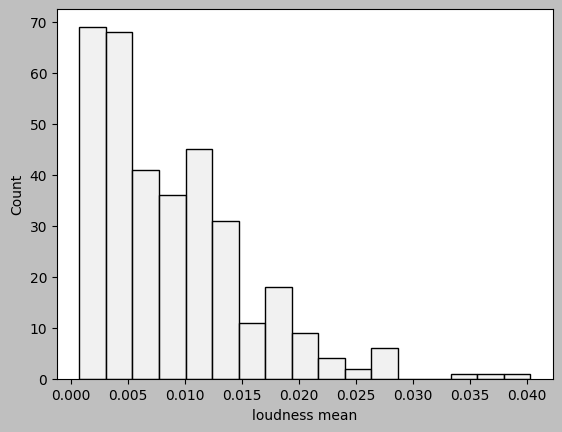

In [81]:
sns.set_palette(palette='Greys')
sns.histplot(data=df, x='loudness mean')

<Axes: xlabel='loudness std dev', ylabel='Count'>

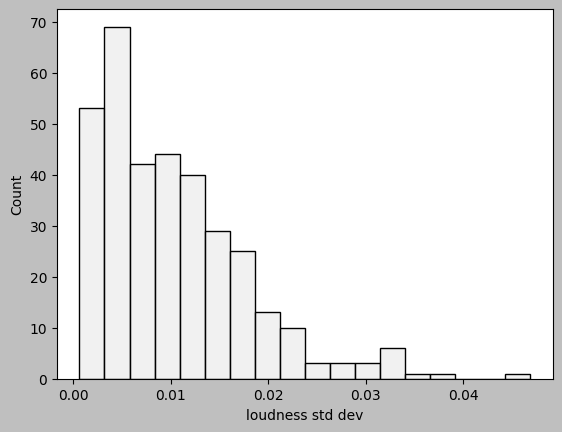

In [82]:
sns.set_palette(palette='Greys')
sns.histplot(data=df, x='loudness std dev')


<Axes: xlabel='loudness range', ylabel='Count'>

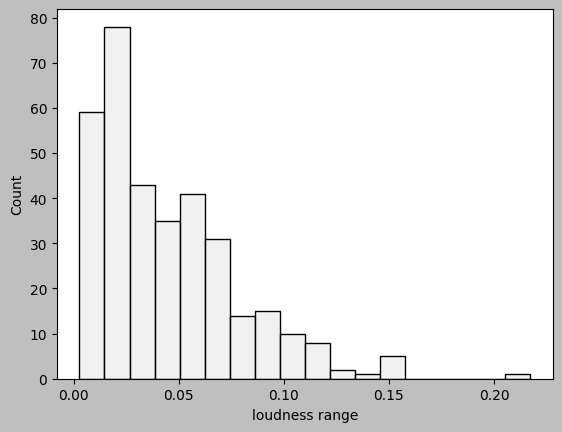

In [83]:
sns.set_palette(palette='Greys')
sns.histplot(data=df, x='loudness range')

Loudness looks like a right-skewed normal distribution, with the left tail cut off. Somewhat expected.

Trying again to see if right skew but with all other features.

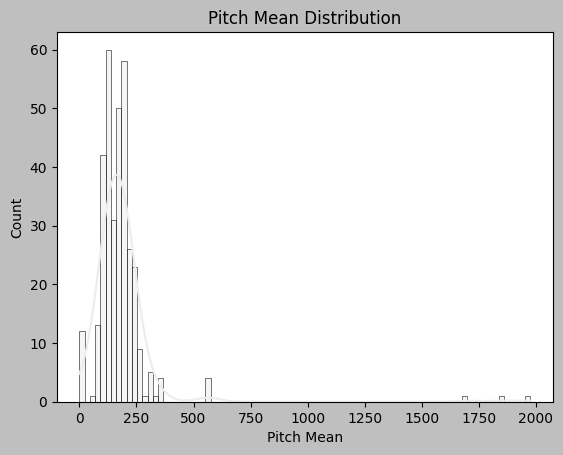

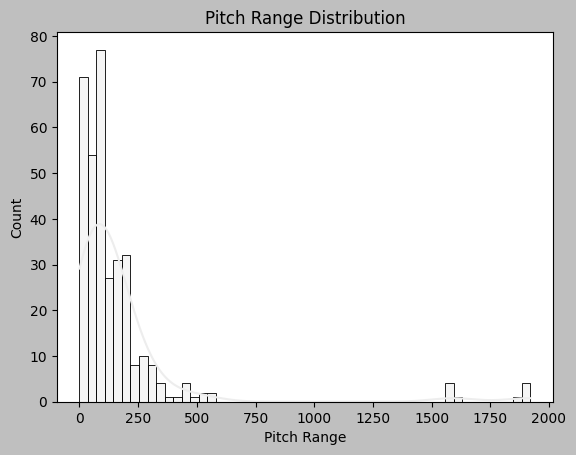

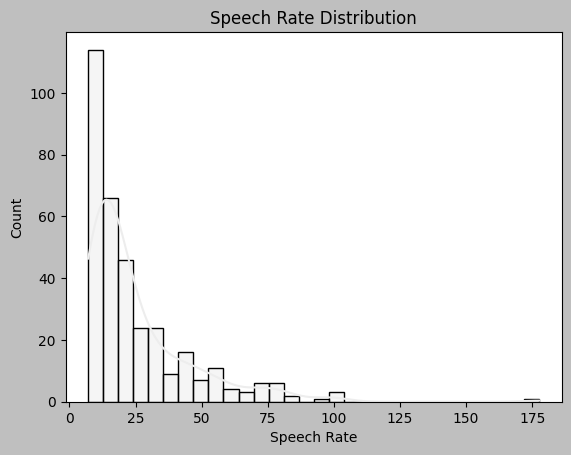

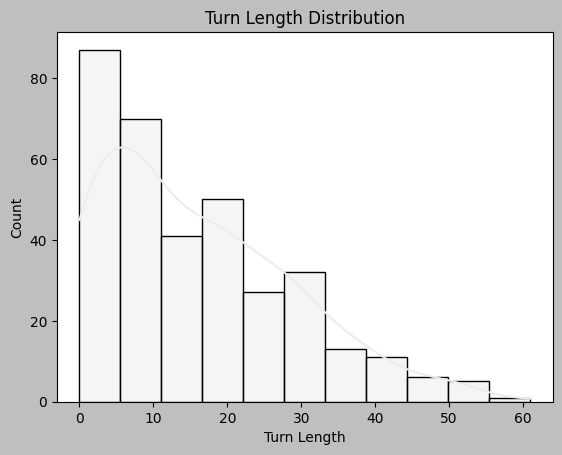

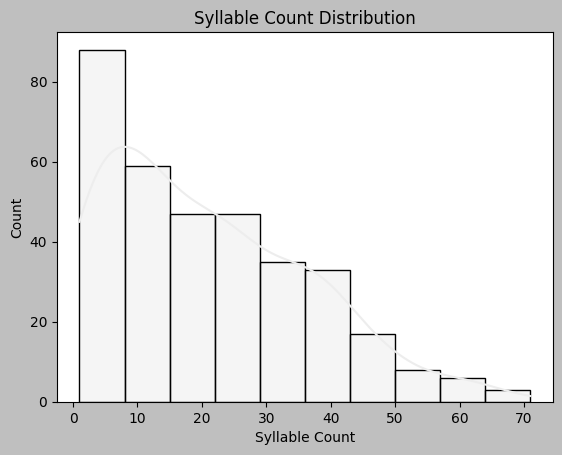

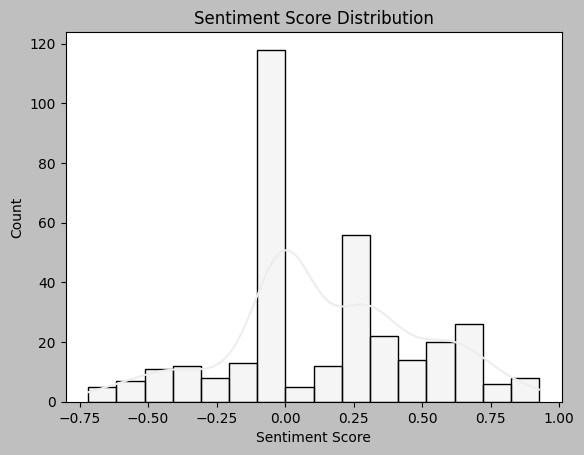

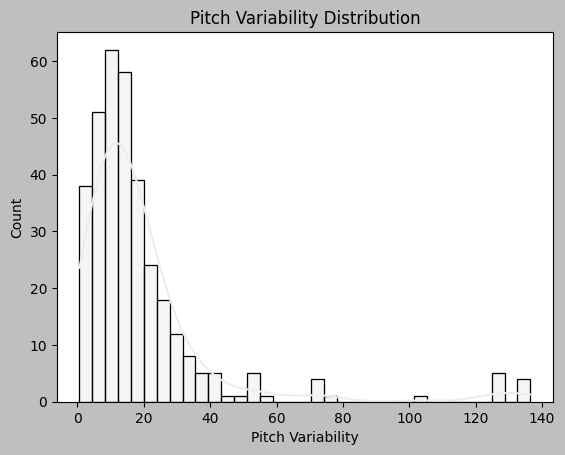

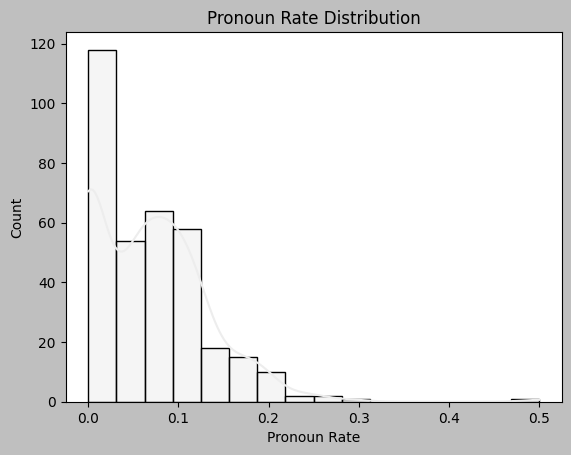

In [85]:
sns.set_palette(palette='Greys')

features = [
    "pitch mean", "pitch range", "speech rate", "turn_length",
    "syllable_count", "sentiment_score", "pitch_variability", "pronoun rate"
]

# Loop through each feature and create a separate figure
for feature in features:
    plt.figure()  # Create a new figure
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f"{feature.replace('_', ' ').title()} Distribution")  # Format title
    plt.xlabel(feature.replace('_', ' ').title())  # Format x-axis label
    plt.show()  # Display the figure

<Axes: xlabel='pitch mean', ylabel='Count'>

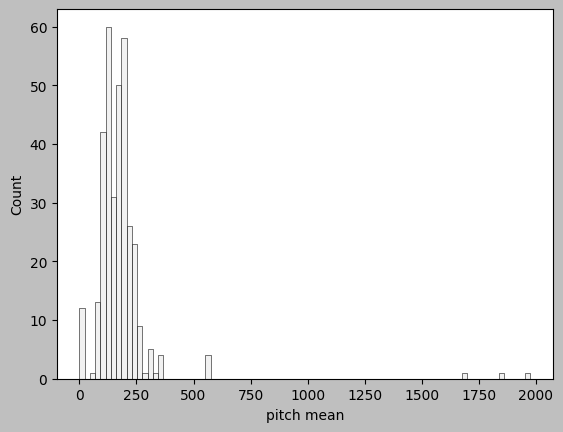

In [86]:
sns.set_palette(palette='Greys')
sns.histplot(data=df, x='pitch mean')

In [88]:
# Not sure how the utterance column is calculated -- by number of unique tokens? Anyway, I'm not doing that.
#df['tokens'] = [ len(l.split()) for l in df.iloc[:,4] ]

#doing token per word, maybe wrong
df['tokens'] = df['sentence_x'].fillna("").apply(lambda x: len(str(x).split()))
df

,file,start time_x,end time_x,sentence_x,speech rate,utterance,repitition,loudness,pitch,speaker,...,pitch range,loudness mean,loudness std dev,loudness range,pronoun rate,turn_length,syllable_count,sentiment_score,pitch_variability,tokens
0,2102B.U43.wav,1970-01-01 00:00:00.000000186,1970-01-01 00:00:00.000000188,oh that would be a shame,49.61,5.0,8,0.02,139.21,Switchboard.1056,...,191.622265,0.019531,0.019072,0.074949,0.00,5.0,6,-0.4767,29.821882,6
1,2105B.U15.wav,1970-01-01 00:00:00.000000058,1970-01-01 00:00:00.000000062,i think it is more fun to play than it is to w...,33.24,12.0,20,0.01,181.91,Switchboard.1133,...,170.816969,0.009657,0.011876,0.039924,0.17,11.0,12,0.7397,32.049979,13
2,2107A.U58.wav,1970-01-01 00:00:00.000000233,1970-01-01 00:00:00.000000235,really,63.96,0.0,6,0.00,233.28,Switchboard.1053,...,198.360286,0.003790,0.004043,0.015679,0.00,0.0,3,0.0000,21.808714,1
3,2107B.U25.wav,1970-01-01 00:00:00.000000080,1970-01-01 00:00:00.000000081,oh uh huh,75.40,1.0,9,0.01,208.07,Switchboard.1135,...,91.097739,0.011138,0.010884,0.041635,0.00,0.0,1,0.0000,9.641132,3
4,2111B.U35.wav,1970-01-01 00:00:00.000000136,1970-01-01 00:00:00.000000140,because i wish we would do more noise at work ...,26.37,11.0,23,0.01,313.16,Switchboard.1106,...,350.512256,0.012050,0.014729,0.047161,0.08,11.0,14,0.4019,36.753618,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,2395B.U31.wav,1970-01-01 00:00:00.000000149,1970-01-01 00:00:00.000000161,quite a bit of time on one story they will hav...,8.36,36.0,88,0.01,115.56,Switchboard.1162,...,27.584603,0.008929,0.010494,0.050534,0.03,34.0,38,0.2975,4.988429,37
339,4519A.U14.wav,1970-01-01 00:00:00.000000093,1970-01-01 00:00:00.000000104,um they were where i came from in uh Dallas no...,9.22,13.0,31,0.00,97.93,Switchboard.1199,...,39.645753,0.004679,0.005656,0.026196,0.09,10.0,12,0.2960,9.864243,14
340,4523A.U10.wav,1970-01-01 00:00:00.000000071,1970-01-01 00:00:00.000000084,someone buys a a handgun and like i say a week...,8.42,40.0,113,0.00,91.29,Switchboard.1638,...,1.589071,0.000754,0.001265,0.005081,0.05,36.0,47,-0.4152,0.597482,41
341,4531B.U13.wav,1970-01-01 00:00:00.000000033,1970-01-01 00:00:00.000000037,i see i seedo many people listen to country music,25.41,9.0,33,0.01,246.04,Switchboard.1656,...,409.040242,0.009648,0.008131,0.032316,0.00,9.0,15,0.0000,27.519048,10


<Axes: xlabel='tokens', ylabel='Count'>

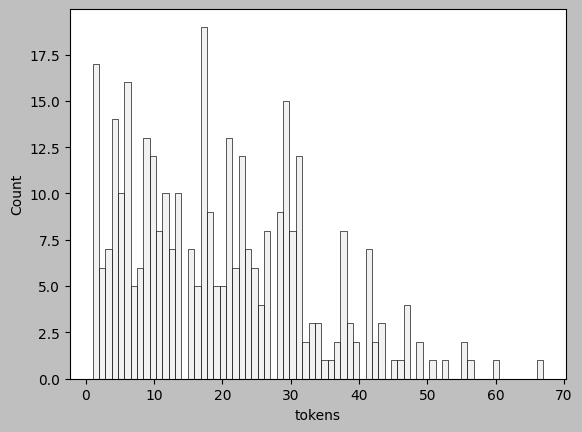

In [89]:
sns.set_palette(palette='Greys')
sns.histplot(data=df, x='tokens', bins=71)

In [20]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'file name', 'start time', 'end time',
       'sentence', 'speech rate', 'utterance', 'repetition', 'pitch mean',
       'pitch std dev', 'pitch range', 'loudness mean', 'loudness std dev',
       'loudness range', 'pronoun rate', 'turn_length', 'syllable_count',
       'sentiment_score', 'pitch_variability', 'generation_decade',
       'utterance duration', 'tokens'],
      dtype='object')

## Feature Extraction done

1. Utterance duration (how long the person was speaking) -- looks like a steady nearly linear decline
1. Speech Rate -- tokens per second
1. Repetition -- Number of words repeated (in sentence? from previous sentence?)
1. Loudness -- Looks negative exponential / Zipf
1. Tokens -- in utterance -- also looks steady nearly linear decline

# Feature Analysis

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


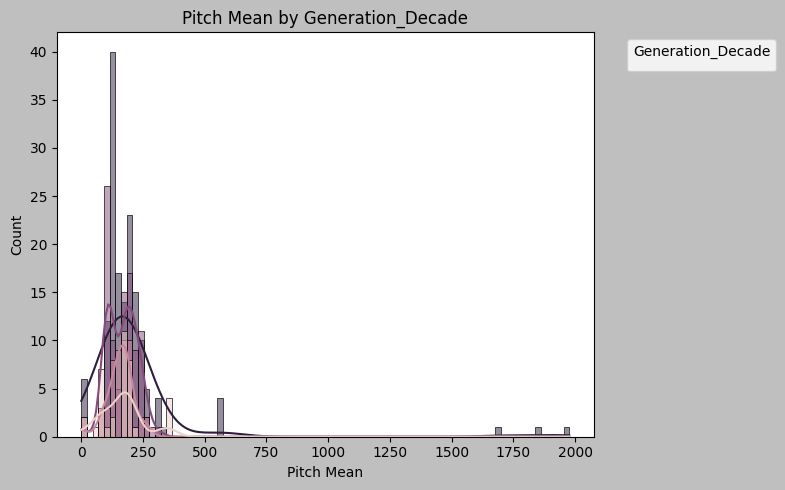

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


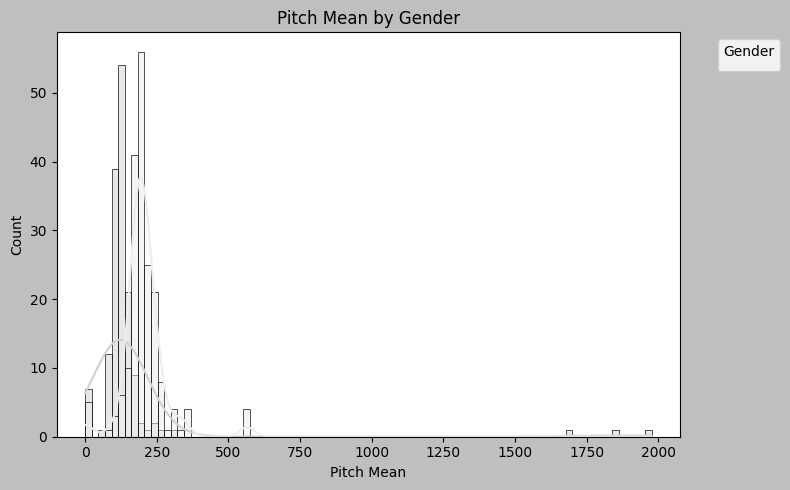

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


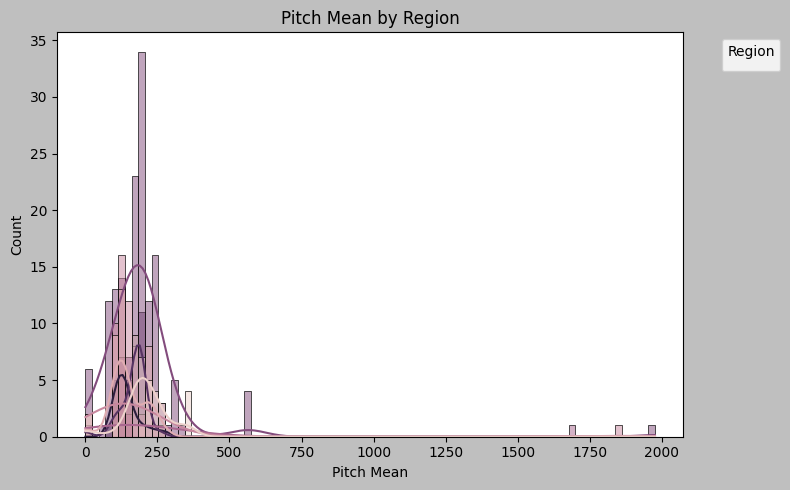

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


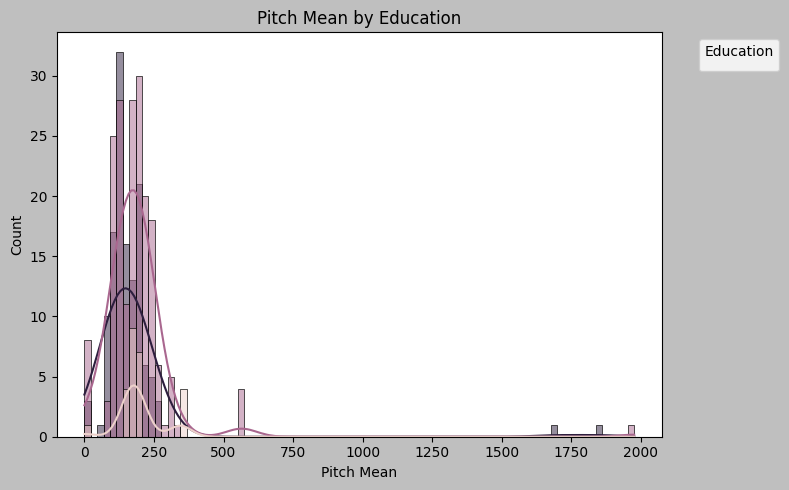

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


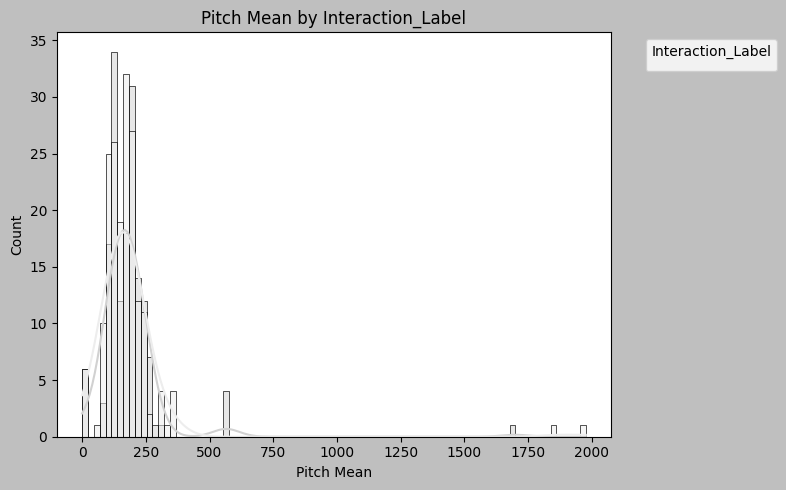

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


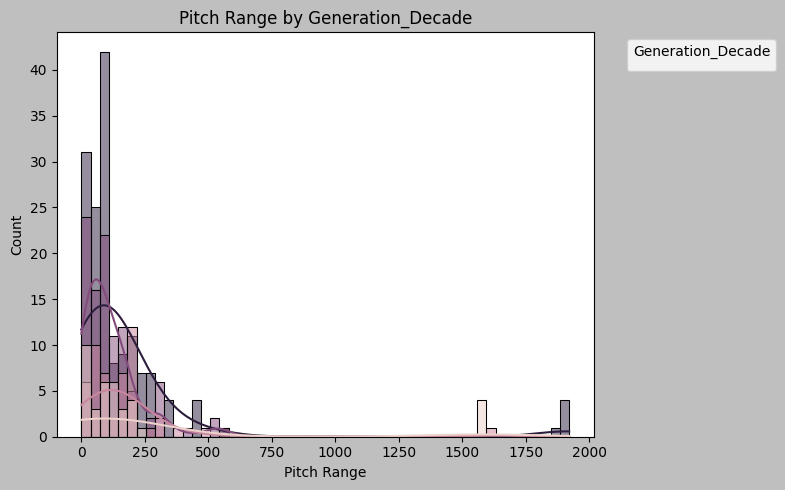

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


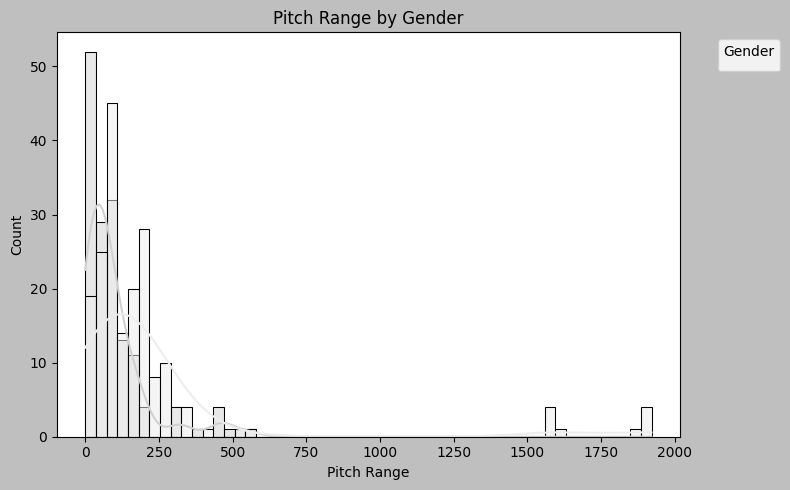

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


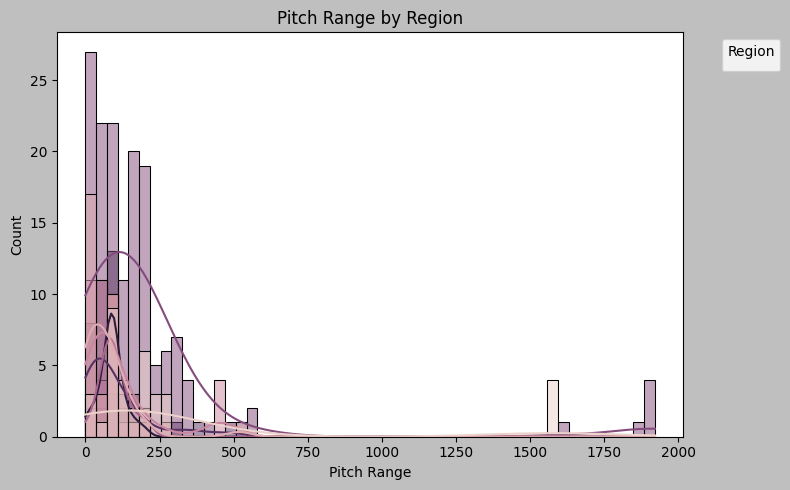

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


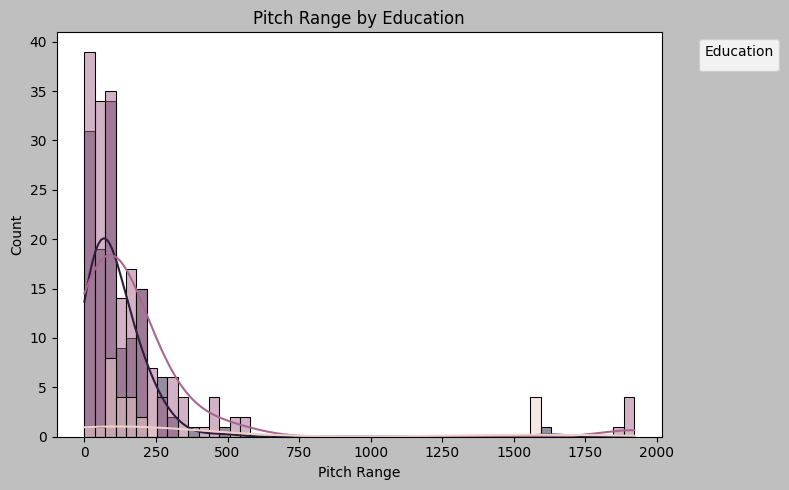

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


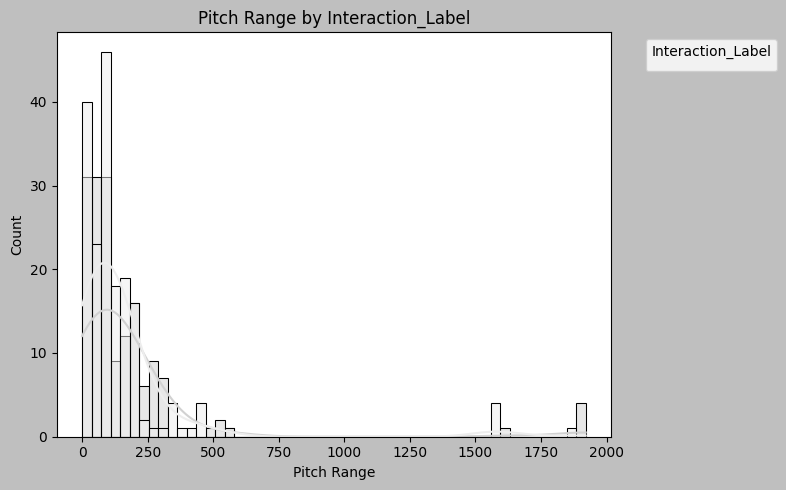

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


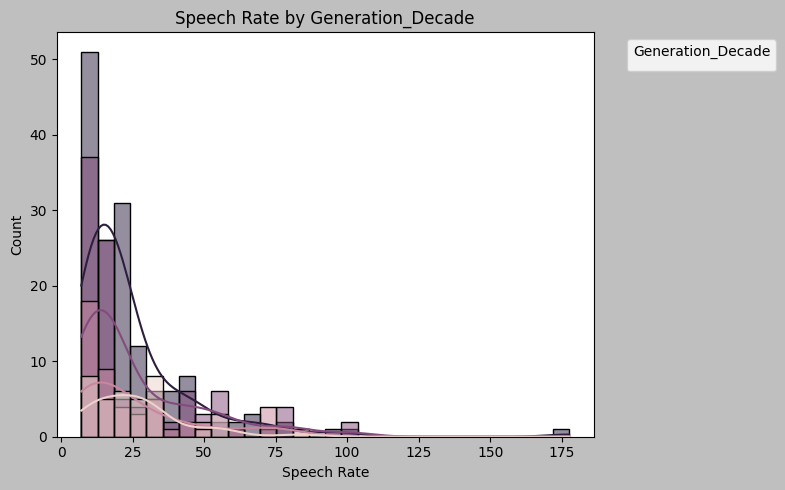

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


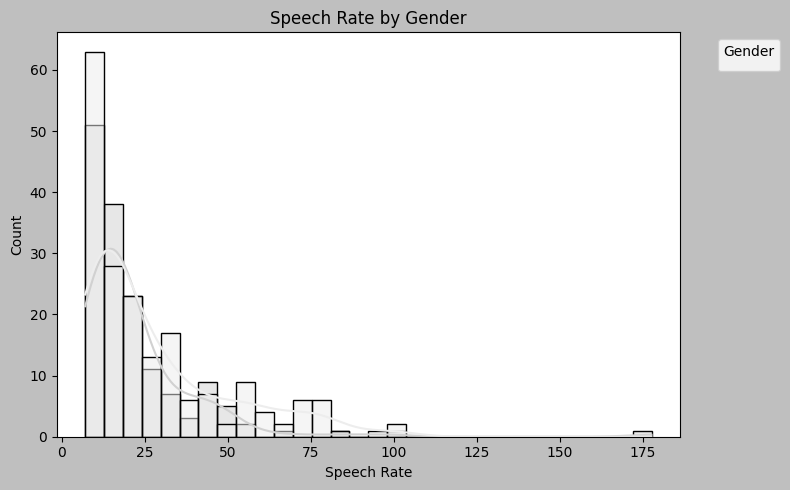

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


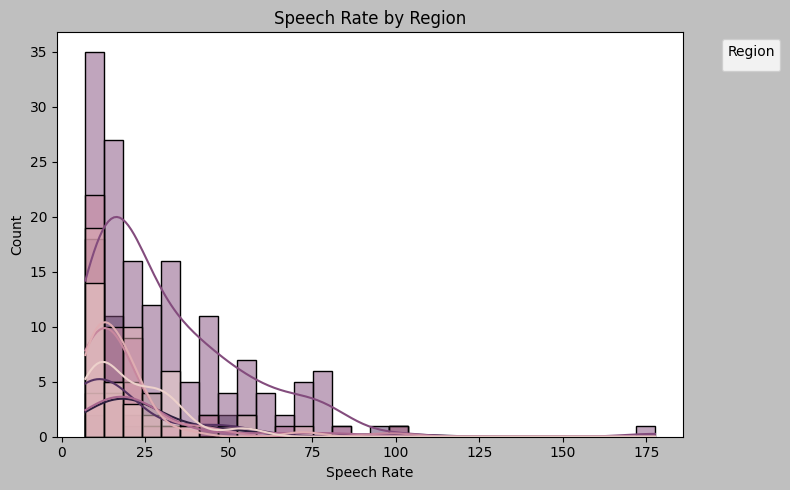

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


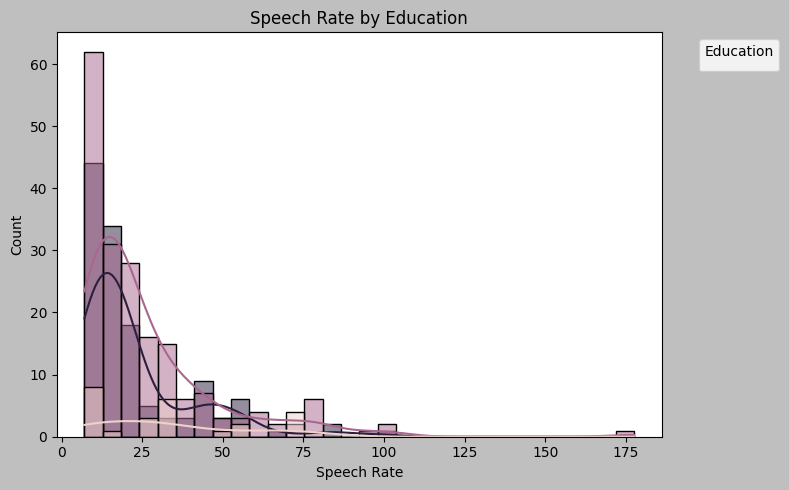

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


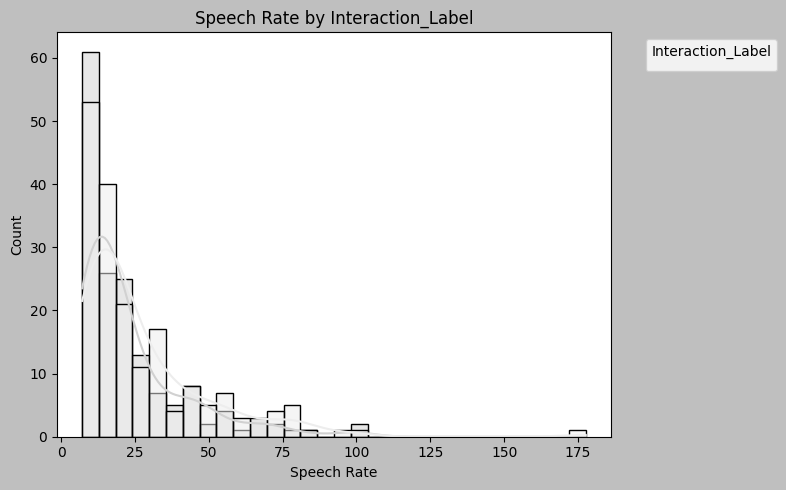

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


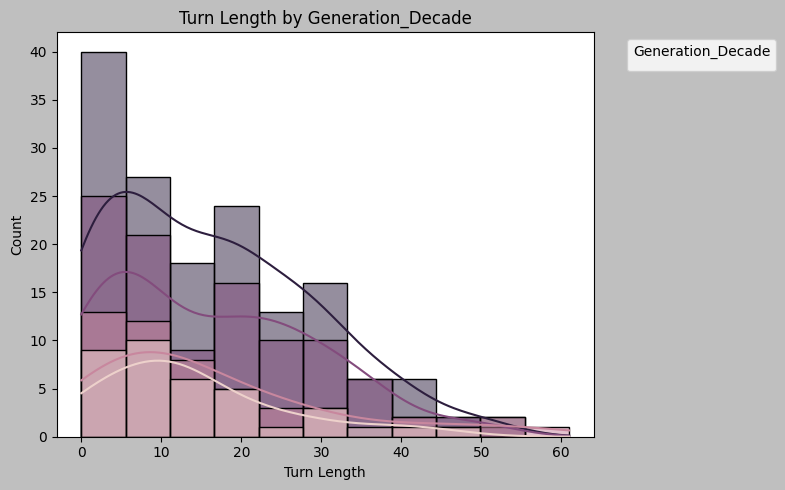

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


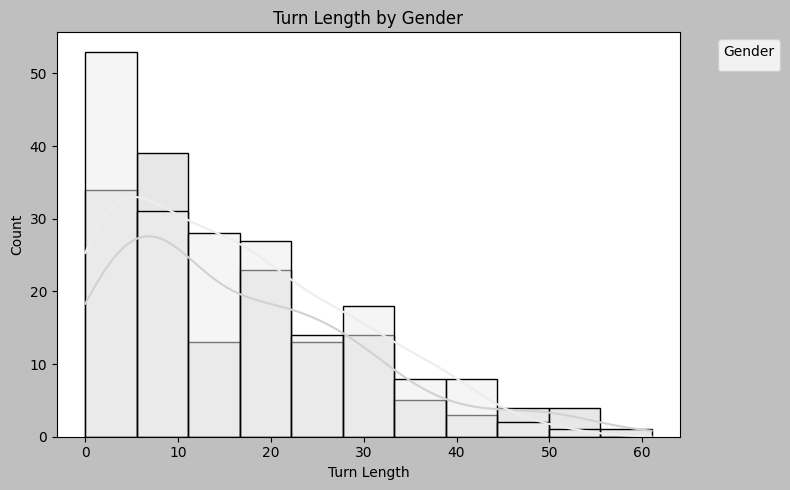

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


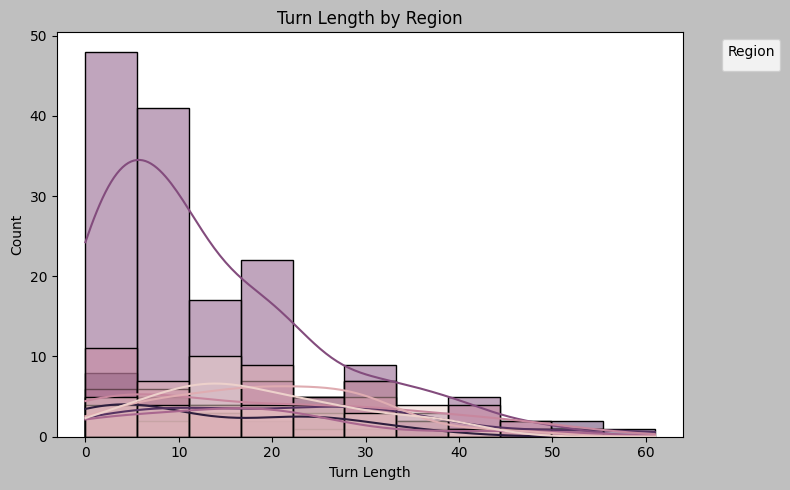

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


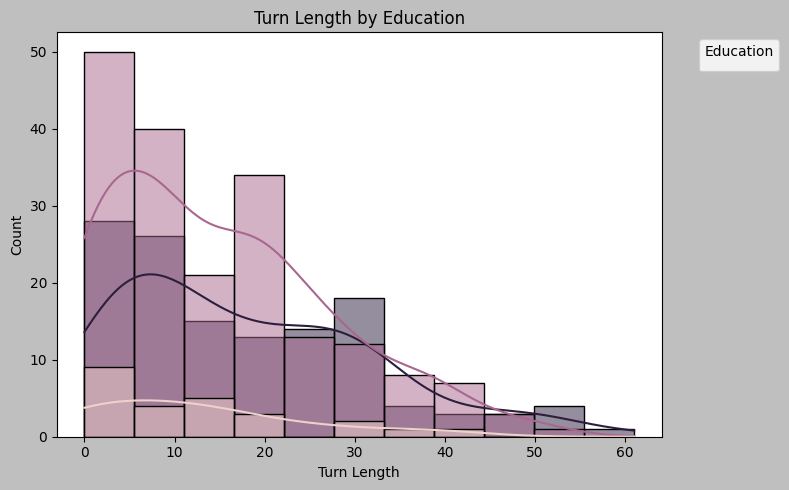

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


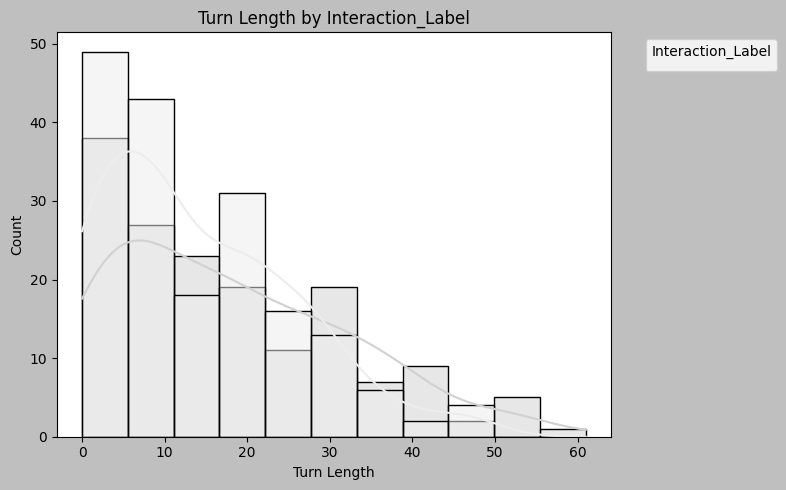

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


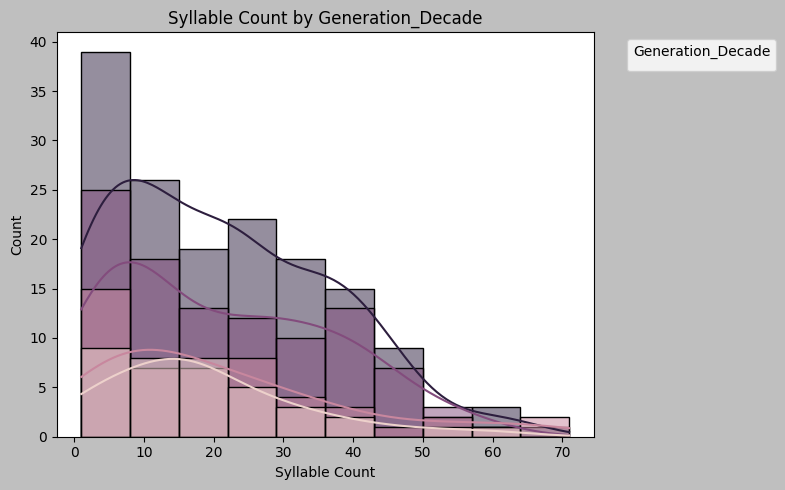

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


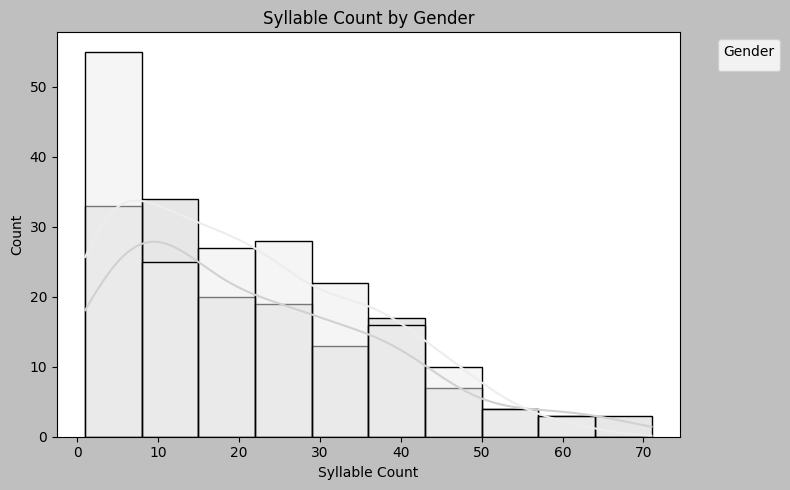

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


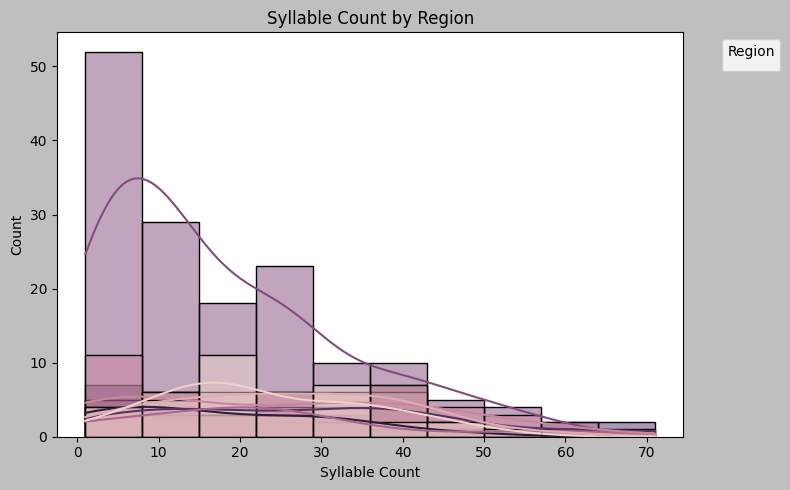

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


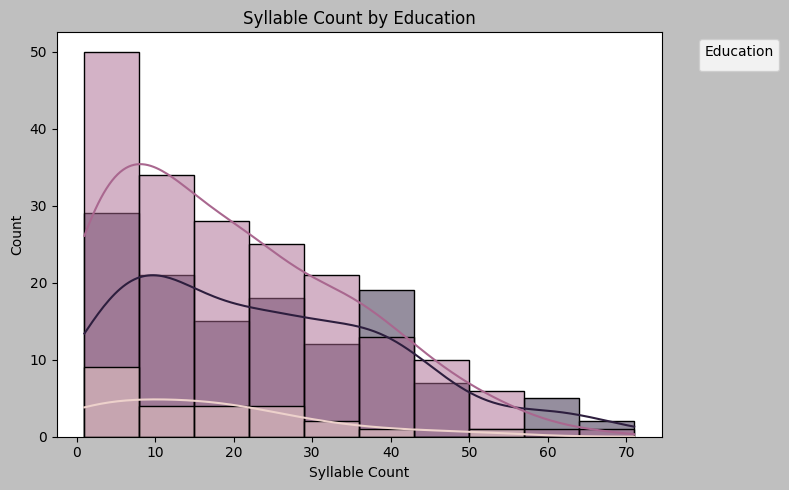

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


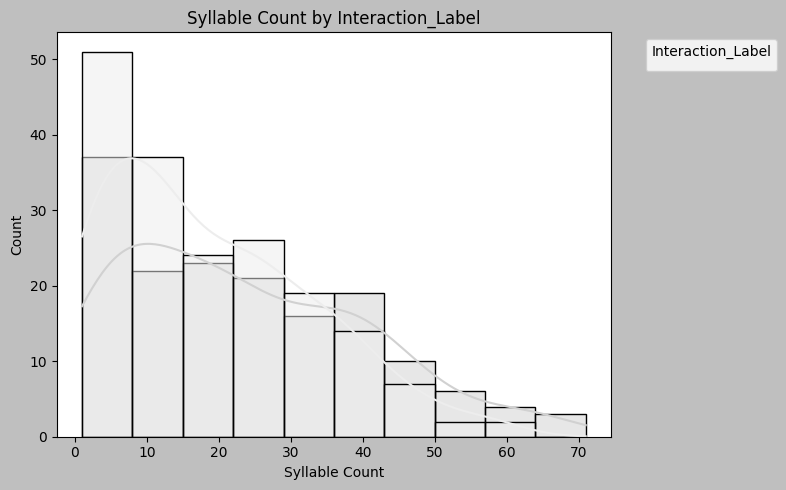

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


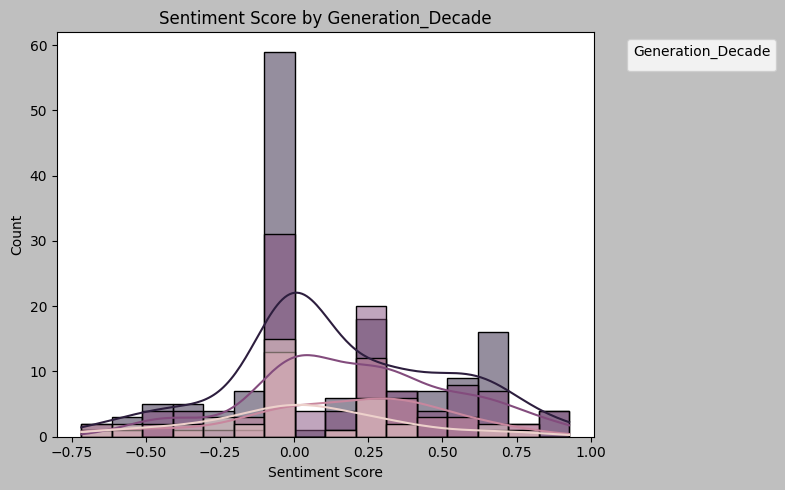

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


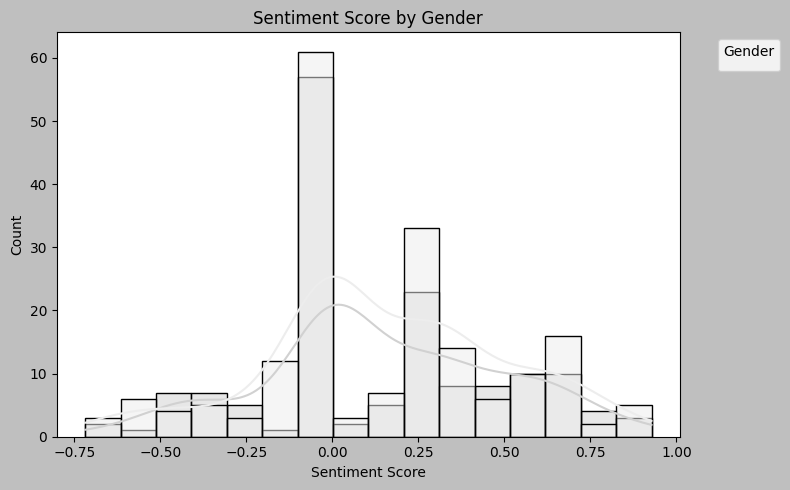

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


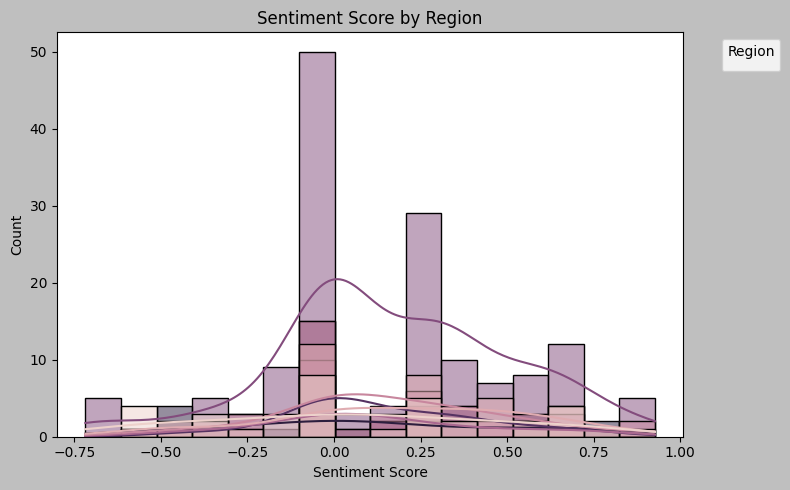

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


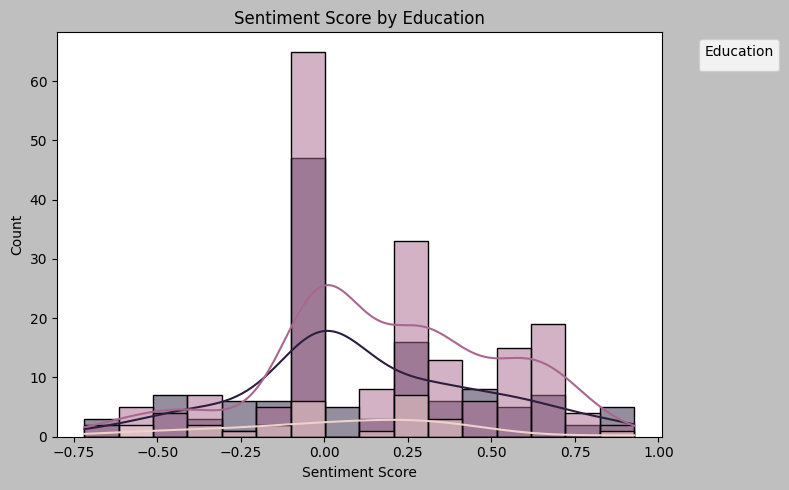

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


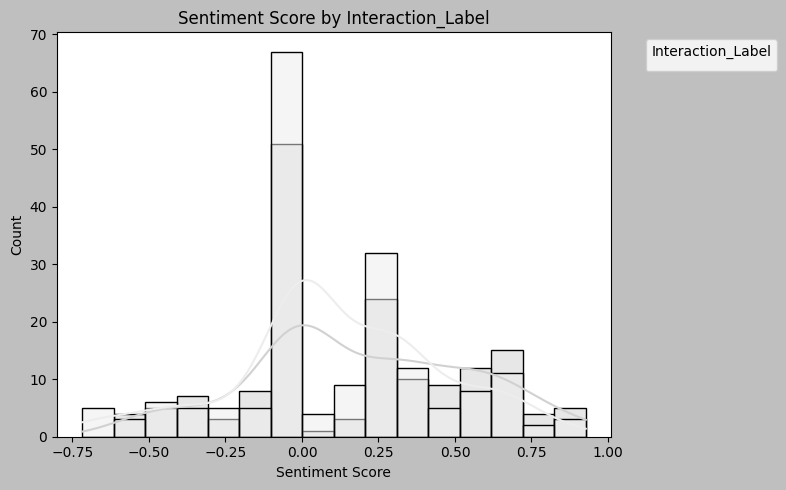

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


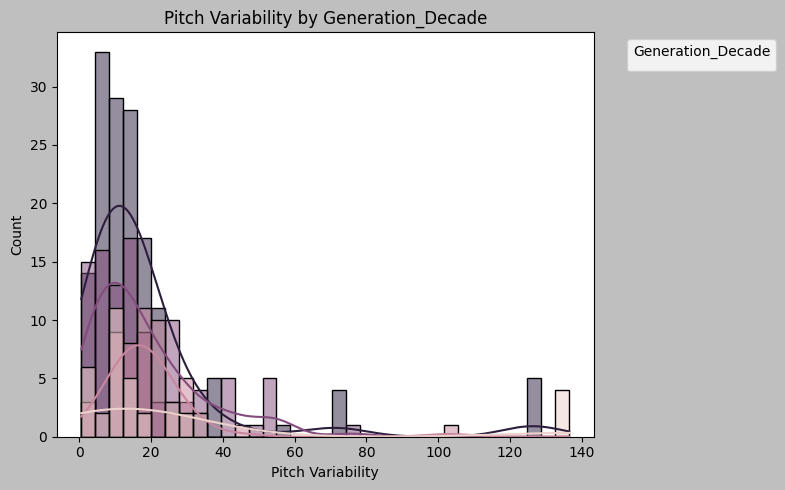

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


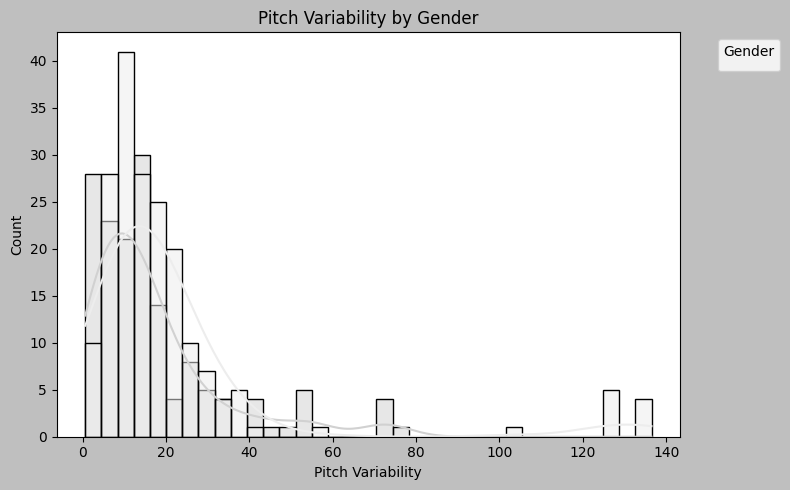

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


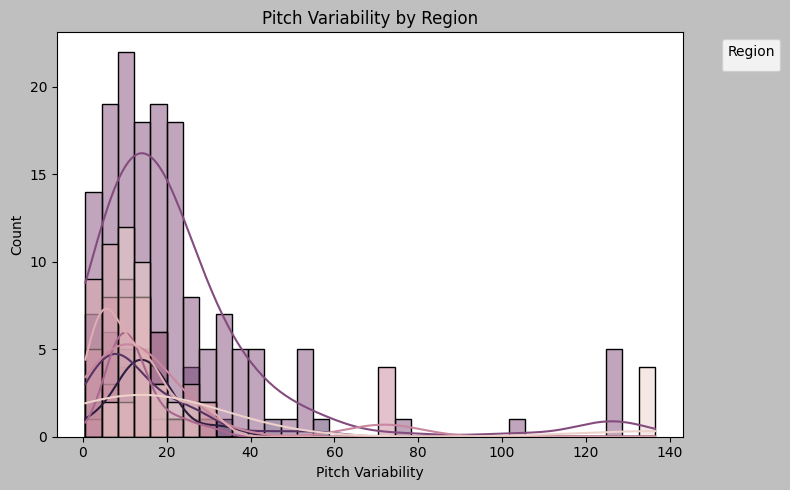

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


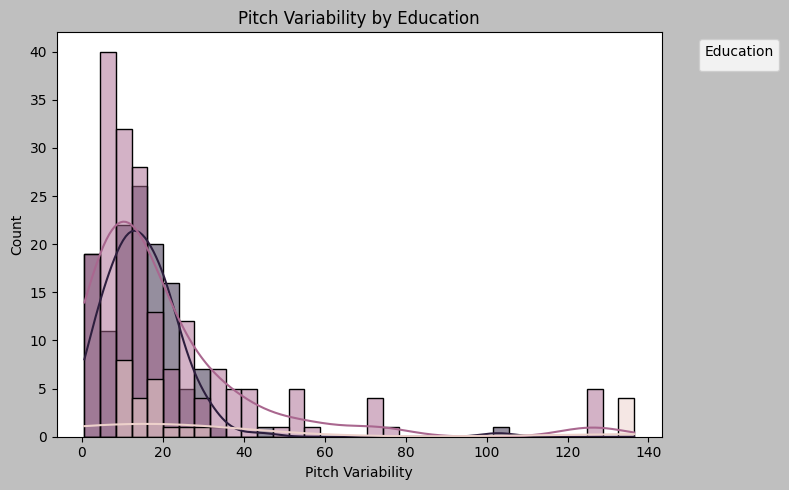

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


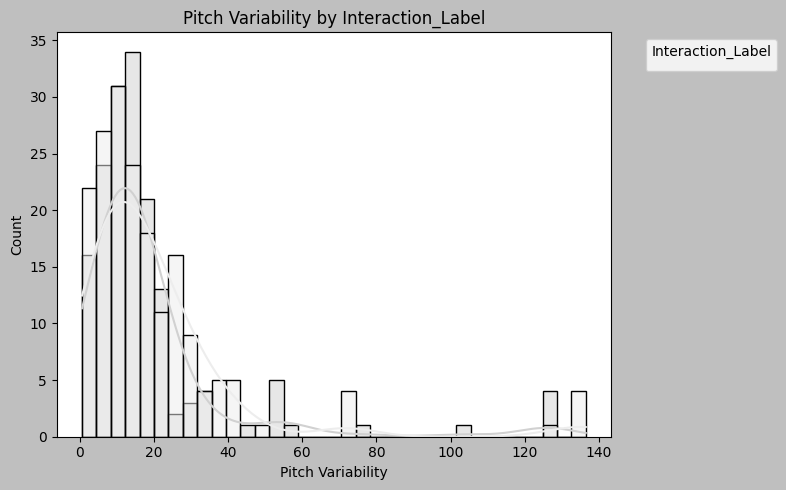

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


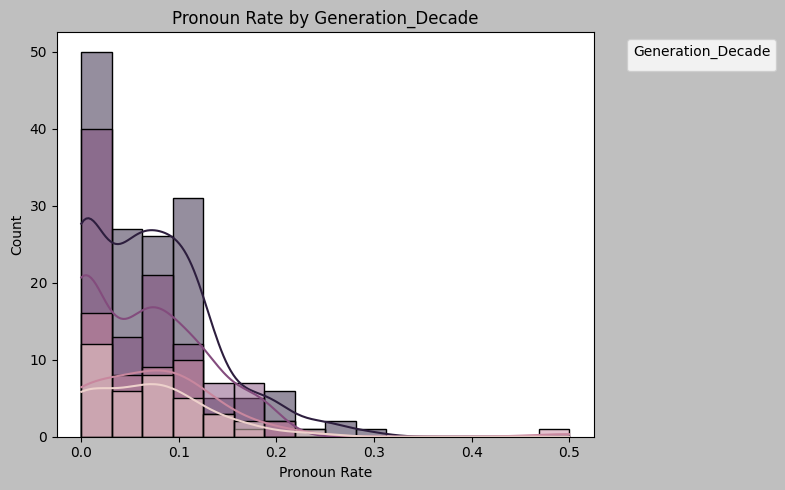

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


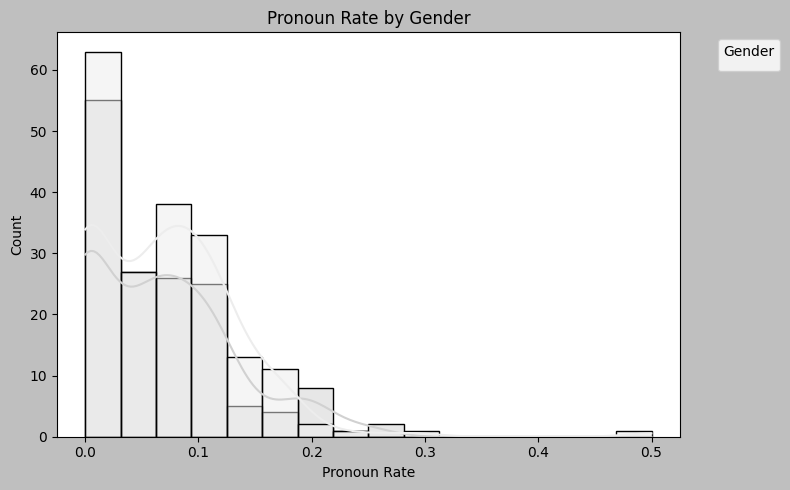

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


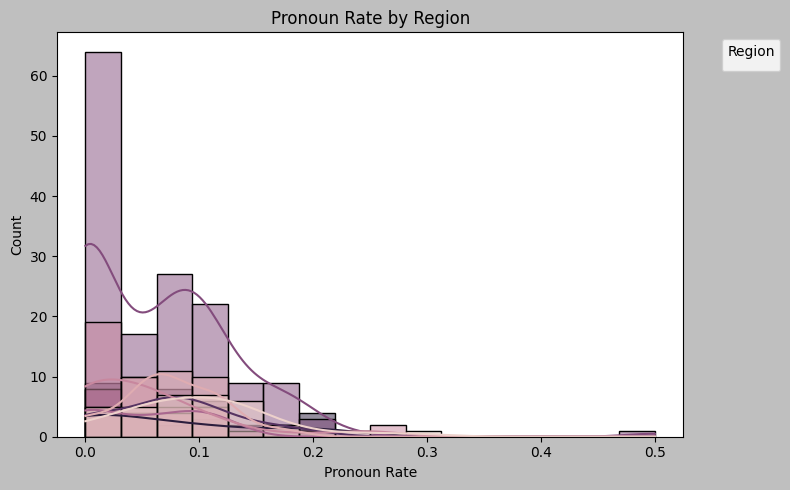

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


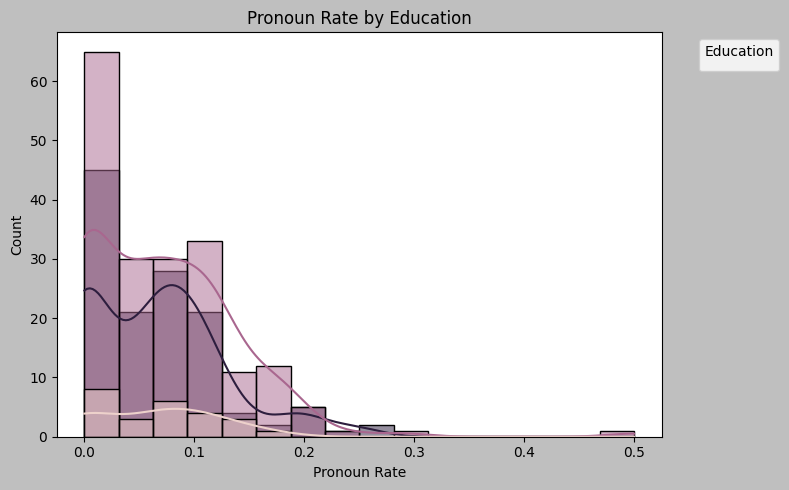

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


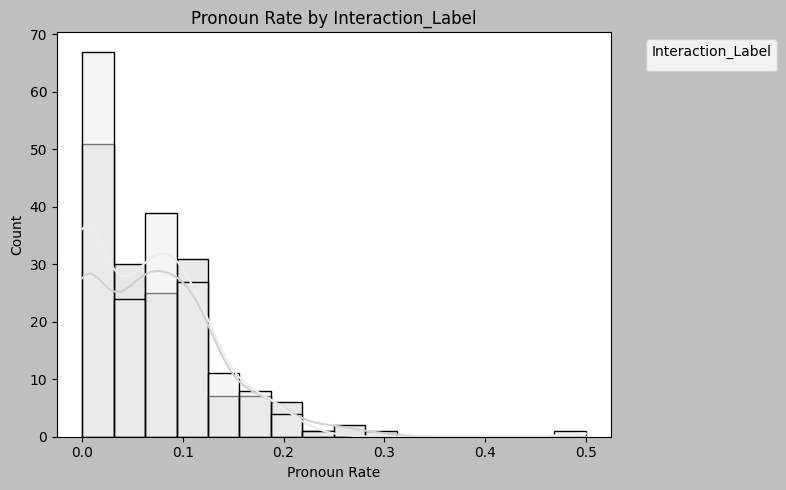

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


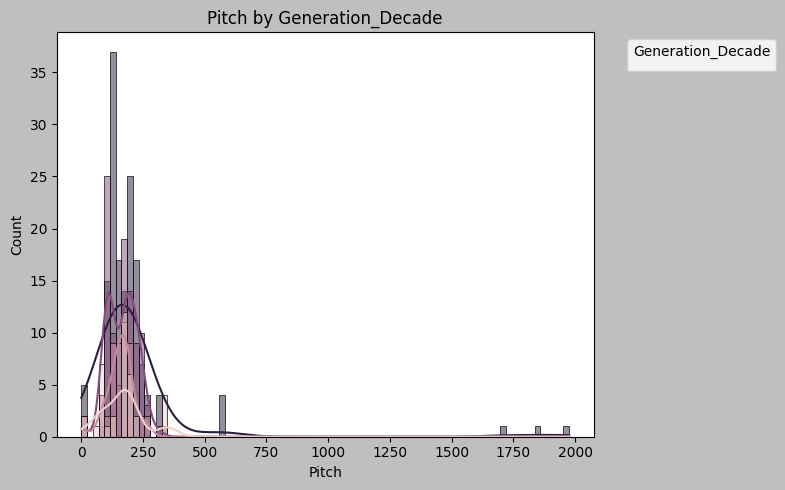

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


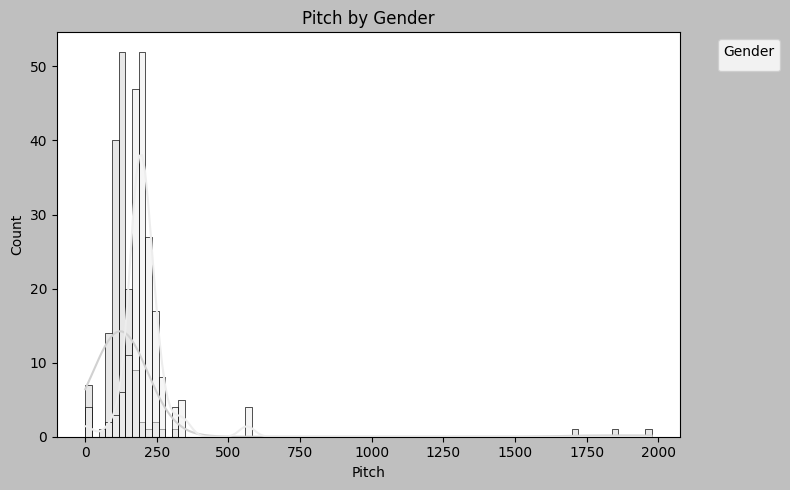

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


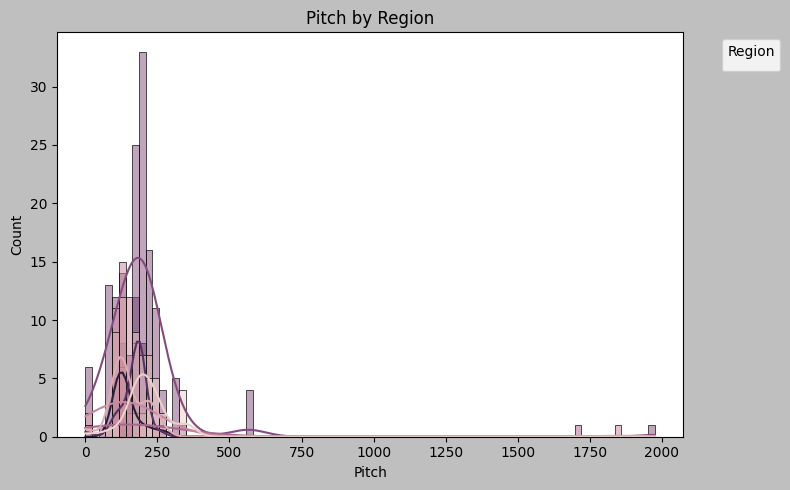

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


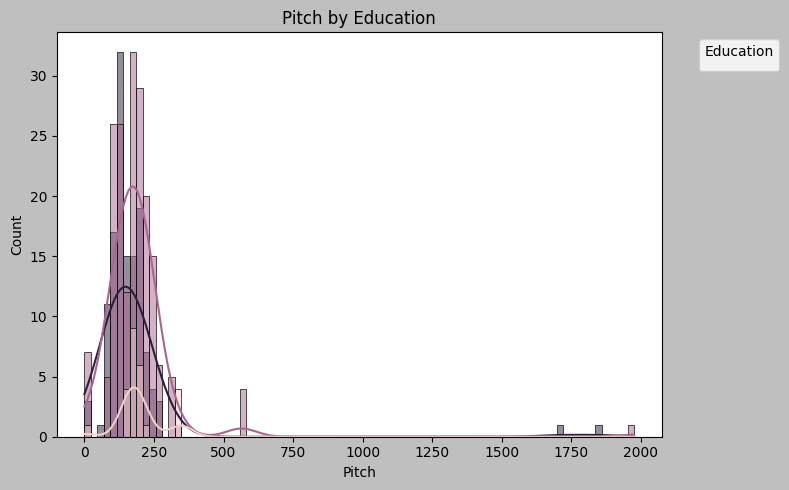

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


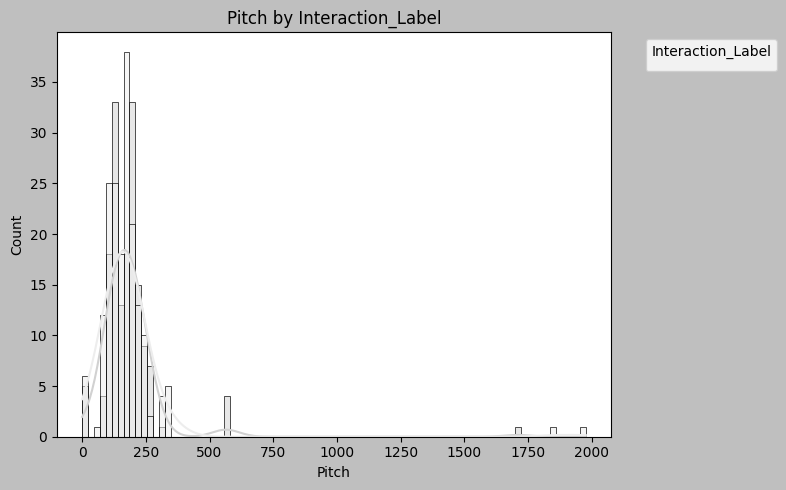

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


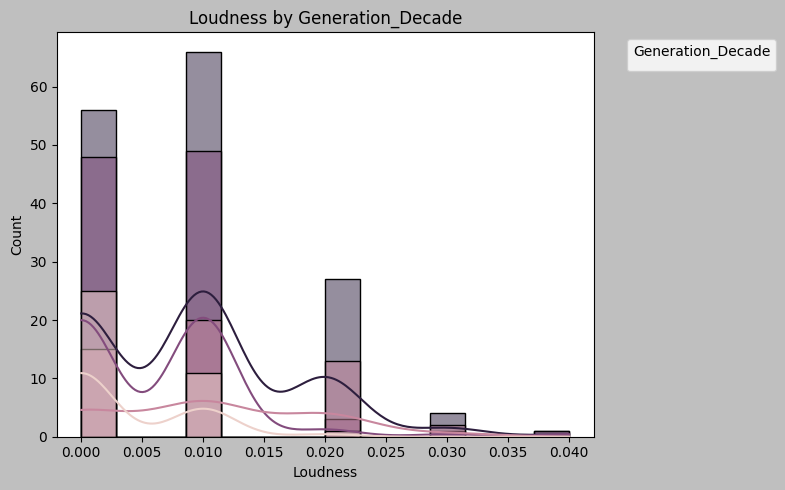

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


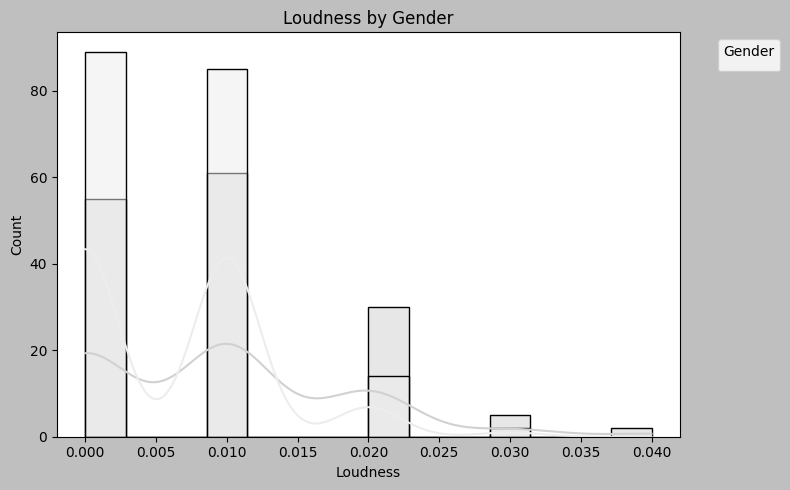

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


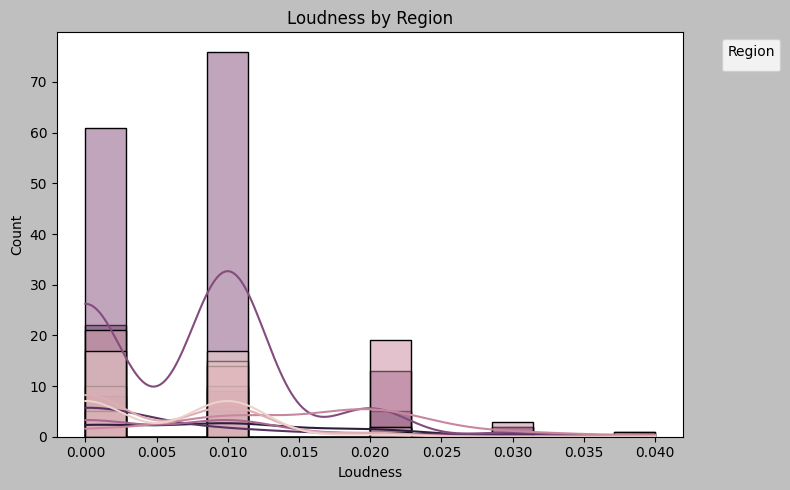

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


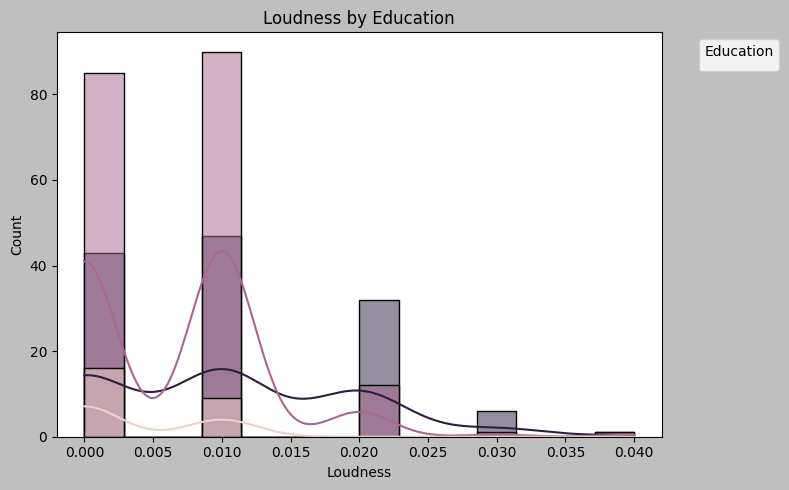

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/237683644.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')


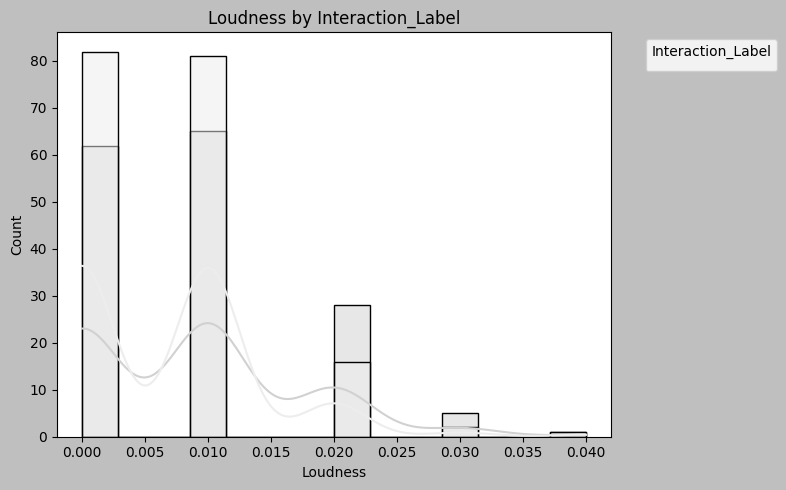

ValueError: Could not interpret value `repition` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [98]:
sns.set_palette(palette='Greys')

features = [
    "pitch mean", "pitch range", "speech rate", "turn_length",
    "syllable_count", "sentiment_score", "pitch_variability", "pronoun rate", "pitch", "loudness",
    "repition", "loudness mean", "loudness std dev", "loudness range", "sentiment_score" 
]

categories = ["generation_decade", "gender", "region", "education", "interaction_label"]

for feature in features:
    for category in categories:
        plt.figure(figsize=(8, 5))
        sns.histplot(data=df, x=feature, hue=category, kde=True, alpha=0.5)
        plt.title(f"{feature.replace('_', ' ').title()} by {category.title()}")
        plt.xlabel(feature.replace('_', ' ').title())  
        plt.ylabel("Count")
        plt.legend(title=category.title(), bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()  # Adjust layout to make space for legend
        plt.show()  


red curve and blue curve looks wierd 
which regions are they (break it up by region or gender)
do decode to show legend (interested in seeing regions)

In [ ]:
plt.style.use("grayscale")
sns.set_palette(palette='Greys')

features = [
    "pitch mean", "pitch range", "speech rate", "turn_length",
    "syllable_count", "sentiment_score", "pitch_variability", "pronoun rate"
]

categories = ["generation decade", "gender", "region", "education"]

for feature in features:
    for category in categories:
        plt.figure(figsize=(8, 5))  #
        sns.histplot(data=df, x=feature, hue=category, kde=True, alpha=0.5)
        plt.title(f"{feature.replace('_', ' ').title()} by {category.title()}")
        plt.xlabel(feature.replace('_', ' ').title())  
        plt.legend(title=category.title())
        plt.show()  

In [ ]:
# First: pitch andgender are usually highly correlated. True in this dataset?

sns.histplot(data=df, x='pitch', hue='gender')

Typical distribution -- no surprises in the bulk of the data -- but there's something weird about the range.

Saving the decoding for later, but the gender = 0 is probably female.

<Axes: >

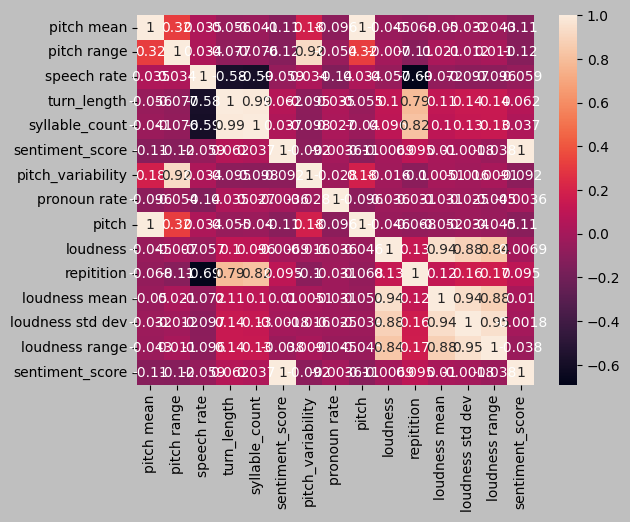

In [102]:
# Correlation?
# sns.heatmap(data=df.corr())
sns.heatmap(df[["pitch mean", "pitch range", "speech rate", "turn_length",
    "syllable_count", "sentiment_score", "pitch_variability", "pronoun rate", "pitch", "loudness",
    "repitition", "loudness mean", "loudness std dev", "loudness range", "sentiment_score"]].corr(), annot=True)

Okay. I'm using pitch as a substitute for gender -- probably not the best idea. However, pitch is:

* Negatively correlated with utterance, tokens and utterance duration --> women speak less than men
* Positively correlated with speech rate --> women speak faster than men
* Positively correlated with loudness --> women speak louder
* Positively correlated with pronoun rate --> women speak about personal topics more
* Negatively correlated with repetition --> men repeat themselves more

... but all of these are weak correlations

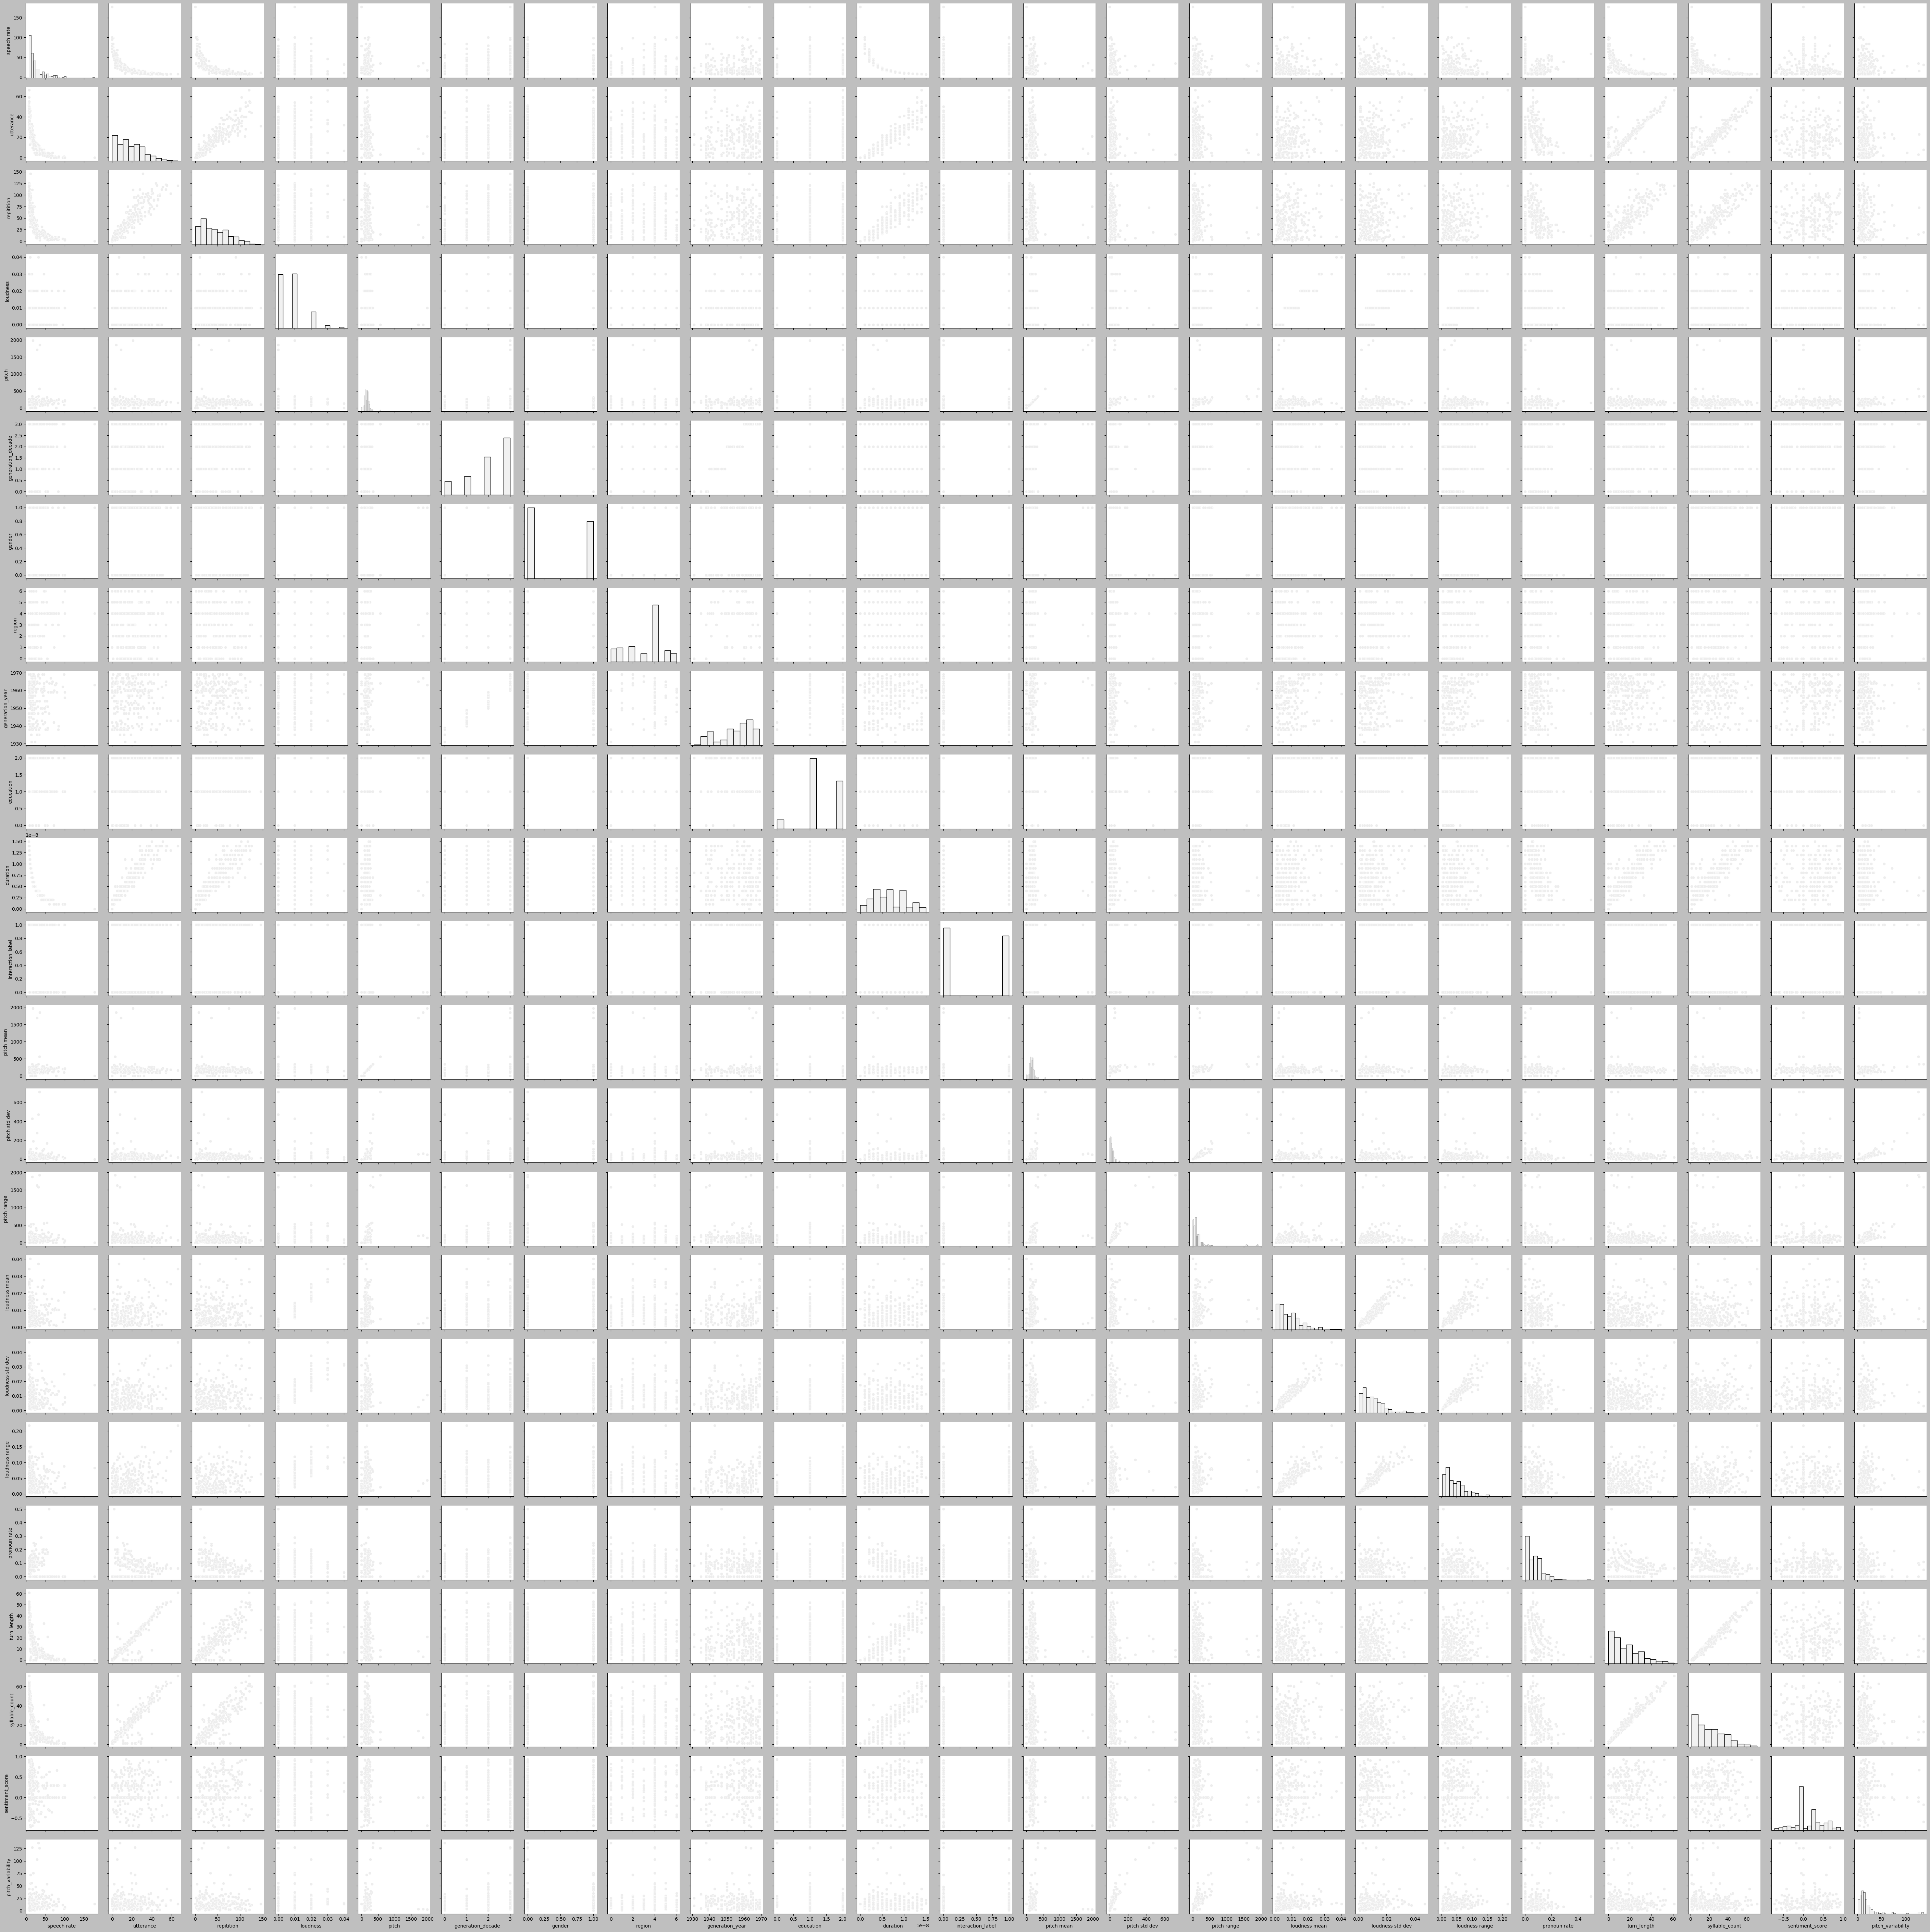

In [103]:
sns.pairplot(data=df)

At least one interesting outcomes here, mostly around speech rate vs.:

* utterance
* repitition
* utterance duration
* tokens

... all with negative log distributions. Even (albeit slightly) vs. pitch

In [110]:
# Apply PCA to these numeric columns... but remove pitch because it's so predictive ofgender

from sklearn.decomposition import PCA

pca = PCA(n_components=10)
convo_pca = pca.fit_transform(df[["speech rate", "turn_length", "syllable_count", "sentiment_score", "pronoun rate", "loudness",
    "repitition", "loudness mean", "loudness std dev", "loudness range"]])
convo_pca



array([[-4.76988523e+01,  4.64715147e+00,  2.35239095e+00, ...,
         8.70211784e-03,  1.05557128e-03,  5.15863176e-04],
       [-2.74348373e+01, -3.52222044e+00,  4.80974343e+00, ...,
         3.12347285e-03,  3.75970356e-04, -1.44462786e-03],
       [-5.79719345e+01,  1.49318864e+01, -3.09397548e+00, ...,
        -1.50472524e-03,  1.42614540e-03,  4.98626545e-04],
       ...,
       [ 7.51698080e+01,  1.61884510e+01, -9.16290378e+00, ...,
         6.72079300e-04, -1.91675921e-04, -2.44997314e-04],
       [-1.34798803e+01, -6.38589415e+00, -7.09801627e-01, ...,
         5.60428954e-03, -8.34053775e-04,  3.94601663e-04],
       [ 7.43013378e+01,  1.60656935e+01, -1.58836929e+00, ...,
        -4.41730177e-04,  7.27510804e-04,  9.50984368e-04]],
      shape=(343, 10))

In [112]:
new_utterance = df.iloc[[0]]

In [115]:
features = ["speech rate", "turn_length", "syllable_count", "sentiment_score", 
            "pronoun rate", "loudness", "repitition", "loudness mean", 
            "loudness std dev", "loudness range"]


In [116]:
new_utterance_loadings = pca.transform(new_utterance[features])
print("Utterance Fingerprint:", new_utterance_loadings)


Utterance Fingerprint: [[-4.76988523e+01  4.64715147e+00  2.35239095e+00  6.35353315e-01
  -6.16070675e-01 -6.50081905e-02  3.36074104e-02  8.70211784e-03
   1.05557128e-03  5.15863176e-04]]


In [107]:
convo_pca.shape

(343, 11)

In [142]:
df.columns = df.columns.str.strip()

In [143]:
group_keys = ["gender", "region", "education", "generation_decade"]
speech_features = [
    "speech rate", "utterance", "repitition", "loudness", "pronoun rate",
    "turn_length", "syllable_count", "sentiment_score", "pitch_variability"
]

In [144]:
#note reset.index() makes result remain df with columns intact
df_grouped = df.groupby(group_keys)[speech_features].agg(["mean", "median", "std", "min", "max"]).reset_index()

/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_55550/646106322.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected.fillna(df_selected.mean(), inplace=True)


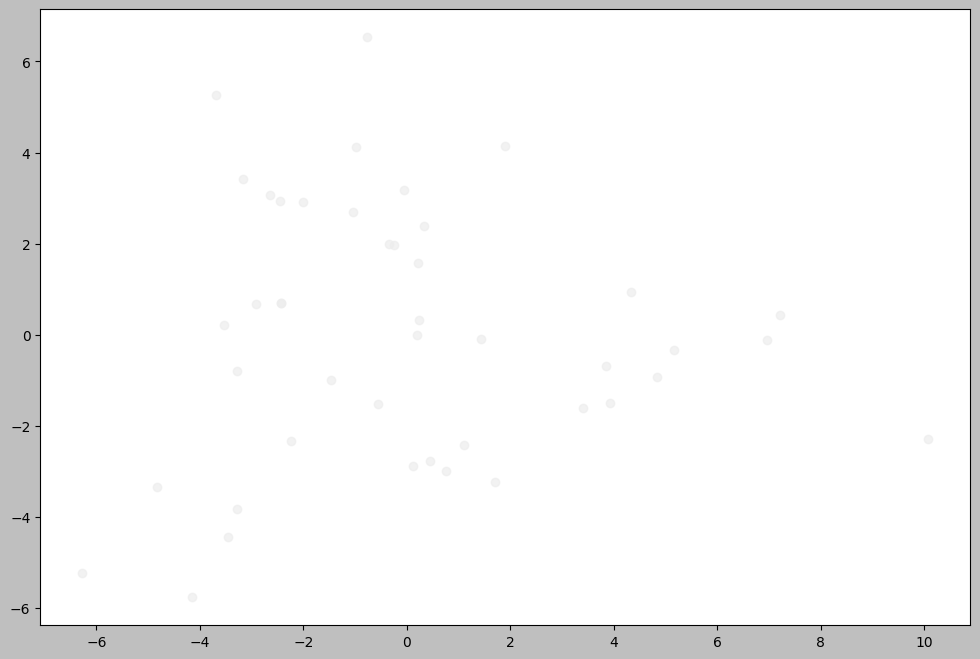

In [146]:
from sklearn.preprocessing import StandardScaler

stat_to_use = ("mean", "median", "std", "min", "max")  # Change to "median" if desired
df_selected = df_grouped.loc[:, (slice(None), stat_to_use)]  # Extract only the chosen statistic

# Flatten column names
df_selected.columns = [col[0] if col[1] == '' else f"{col[0]}_{col[1]}" for col in df_selected.columns]

df_selected.fillna(df_selected.mean(), inplace=True)

# Standardize the selected features before PCA
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected.iloc[:, len(group_keys):])  # Exclude demographic columns

# Apply PCA (reduce to 2 components for visualization)
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(df_scaled)

# Scatter plot of PCA results
plt.figure(figsize=(12, 8))
plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], alpha=0.7)

In [ ]:
#df_grouped = df.groupby(group_keys)[speech_features].agg("mean").reset_index()

In [123]:
#df_grouped = df.groupby(["gender", "region", "education", "generation_decade"])[
    #["speech rate", "utterance", "repitition", "loudness", "pronoun rate",
     #"turn_length", "syllable_count", "sentiment_score", "pitch_variability"]
#].mean().reset_index()

In [ ]:
#df_grouped_standardized = (df_grouped.iloc[:, 4:] - df_grouped.iloc[:, 4:].mean()) / df_grouped.iloc[:, 4:].std()

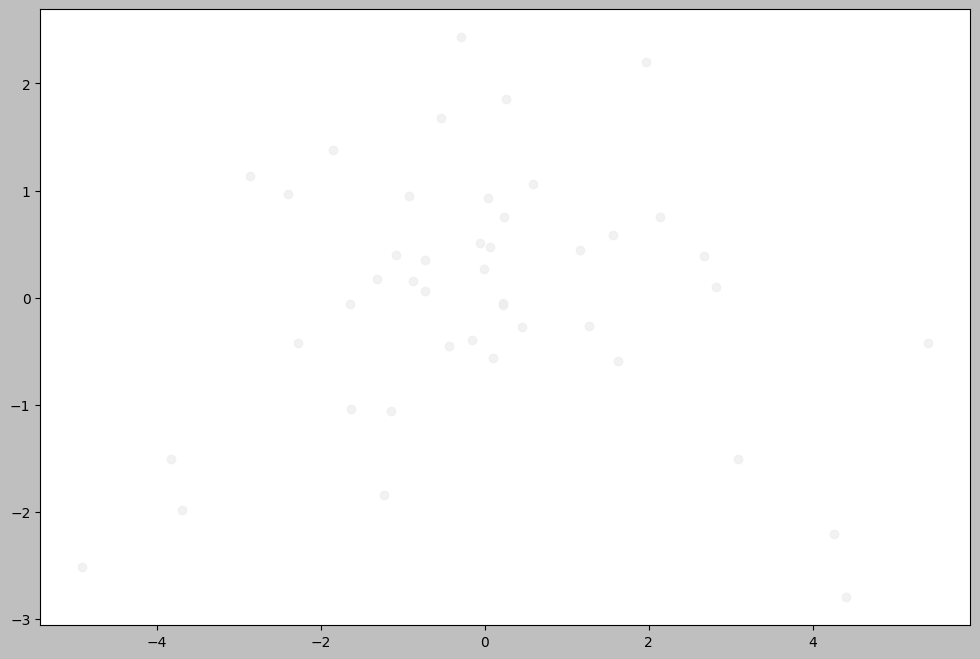

In [120]:
plt.figure(figsize=(12, 8))
plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], alpha=0.7)

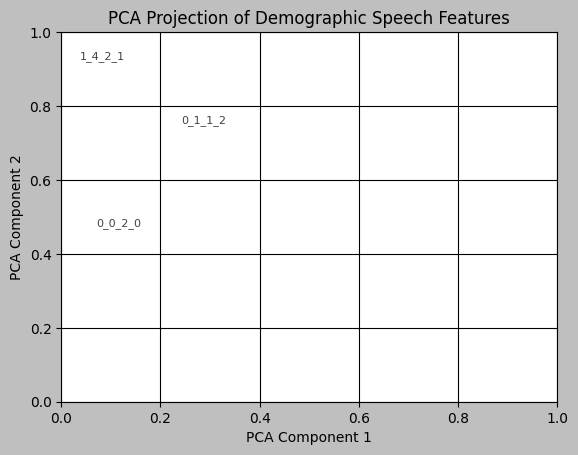

In [ ]:
#or i, label in enumerate(df_grouped.iloc[:, :4].apply(lambda x: "_".join(x.astype(str)), axis=1)):
    #plt.annotate(label, (pca_transformed[i, 0], pca_transformed[i, 1]), fontsize=8, alpha=0.75)

#plt.xlabel("PCA Component 1")
#plt.ylabel("PCA Component 2")
#plt.title("PCA Projection of Demographic Speech Features")
#plt.grid(True)
#plt.show()

In [17]:
evr_df = pd.DataFrame(pca.explained_variance_ratio_)
evr_df

,0
0,8.788285e-01
1,7.262446e-02
2,2.554047e-02
3,2.219766e-02
4,7.650031e-04
5,4.390103e-05
6,3.480740e-08


Two PCs can explain x > 94% of variance. Keeping all of them though.

In [18]:
evr_df['Component'] = [1, 2, 3, 4, 5, 6, 7]
evr_df

,0,Component
0,8.788285e-01,1
1,7.262446e-02,2
2,2.554047e-02,3
3,2.219766e-02,4
4,7.650031e-04,5
5,4.390103e-05,6
6,3.480740e-08,7


In [19]:
sum = 0.
cumsum = []
for i in range(7):
    sum += evr_df.iloc[i,0]
    cumsum.append(sum)
cumsum

[0.8788284781491899,
 0.9514529338099494,
 0.9769934034095011,
 0.9991910611086521,
 0.9999560641638847,
 0.9999999651925987,
 1.0]

In [20]:
evr_df['Total Variance Explained'] = cumsum
evr_df

,0,Component,Total Variance Explained
0,8.788285e-01,1,0.878828
1,7.262446e-02,2,0.951453
2,2.554047e-02,3,0.976993
3,2.219766e-02,4,0.999191
4,7.650031e-04,5,0.999956
5,4.390103e-05,6,1.000000
6,3.480740e-08,7,1.000000


<AxesSubplot:xlabel='Component', ylabel='Total Variance Explained'>

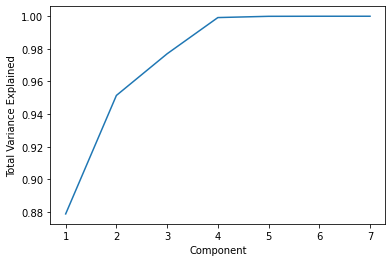

In [21]:
sns.lineplot(data=evr_df, x='Component', y='Total Variance Explained')

In [24]:
# Is is any different if it's normalised?
from sklearn.preprocessing import normalize

pca_norm = PCA(n_components=7)
convo_norm_pca = pca_norm.fit_transform(normalize(df[['speech rate', 'utterance', 'repitition',
                                            'pronoun rate', 'loudness', 'utterance duration', 'tokens']]))
convo_norm_pca
pca_norm.explained_variance_ratio_

array([8.69462739e-01, 5.77698634e-02, 4.49154419e-02, 2.48980522e-02,
       2.86523569e-03, 8.85878377e-05, 8.03410515e-08])

<AxesSubplot:xlabel='Component', ylabel='Total Variance Explained'>

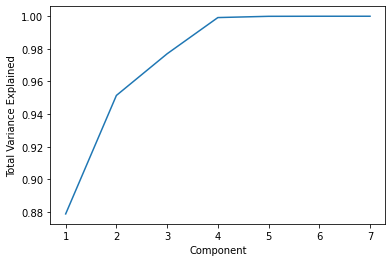

In [25]:
# It's almost the same, but not quite -- still two components for x > 92%.
# Let's use the normalised version.

evr_df = pd.DataFrame(pca.explained_variance_ratio_)
evr_df['Component'] = [1, 2, 3, 4, 5, 6, 7]

sum = 0.
cumsum = []
for i in range(7):
    sum += evr_df.iloc[i,0]
    cumsum.append(sum)

evr_df['Total Variance Explained'] = cumsum

sns.lineplot(data=evr_df, x='Component', y='Total Variance Explained')

In [27]:
for i in range(convo_pca.shape[1]):
    col_name = 'pca' + str(i)
    df[col_name] = convo_norm_pca[:,i]
df

,Unnamed: 0,file,start time,end time,sentence,speech rate,utterance,repitition,pronoun rate,loudness,...,region,utterance duration,tokens,pca0,pca1,pca2,pca3,pca4,pca5,pca6
0,0,2005A.U20.wav,173.970875,185.294250,yeah well my uh my,9.27,4.0,7,0.00,0.00,...,2,11.323375,5,0.157439,-0.007852,0.209547,0.008092,0.554190,-0.001088,-3.401910e-04
1,1,2005A.U23.wav,208.998750,221.283375,finding a place and everybody had duties to pe...,8.55,35.0,107,0.00,0.00,...,2,12.284625,36,-0.457584,-0.099027,-0.043778,0.075922,0.001485,0.000094,-8.107131e-05
2,2,2005A.U24.wav,221.283375,235.435250,and they i know they and well they had well th...,7.42,17.0,16,5.56,0.01,...,2,14.151875,18,-0.211022,0.255379,0.365639,0.060923,0.264300,0.002848,6.932597e-05
3,3,2005A.U42.wav,334.179125,344.231750,it was not necessarily you know like the quant...,10.45,22.0,67,11.11,0.02,...,2,10.052625,24,-0.391447,0.035724,-0.085246,0.032445,0.023165,-0.008671,1.353432e-04
4,4,2005A.U52.wav,390.784625,401.230250,we we don't we we we choose not to deal with t...,10.05,31.0,88,8.33,0.01,...,2,10.445625,32,-0.429650,-0.013616,-0.049888,0.052998,-0.004303,0.000229,5.545455e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,2922,4877B.U18.wav,85.803625,97.423625,and and then i have my um um i have a seven mo...,9.04,37.0,111,5.56,0.01,...,8,11.620000,38,-0.454235,-0.056208,-0.056589,0.073173,-0.009990,0.000104,-7.176066e-07
2923,2923,4880A.U23.wav,135.559250,144.838375,ititit yes okay andand our company has taken t...,11.32,18.0,57,10.53,0.02,...,2,9.279125,19,-0.356375,0.040686,-0.108550,0.014075,0.035727,0.000439,1.791858e-04
2924,2924,4880A.U27.wav,162.316875,165.572000,uh laughter-and and uh,32.26,3.0,18,0.00,0.02,...,2,3.255125,4,0.463826,-0.170064,-0.069186,-0.089352,0.025993,-0.000386,3.537818e-04
2925,2925,4908B.U21.wav,145.560750,155.614125,uh waste material in general and um and purify...,10.44,16.0,71,5.00,0.02,...,2,10.053375,17,-0.389406,-0.088052,-0.171861,0.048537,0.044435,-0.000115,1.556577e-04


<AxesSubplot:xlabel='pca0', ylabel='Count'>

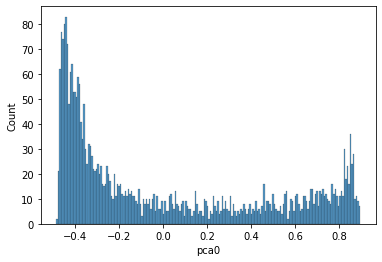

In [28]:
sns.histplot(data=df, x='pca0', bins=200)

Looks like a U-shaped trend, but maybe there are may be different populations on either end?

<AxesSubplot:xlabel='pca0', ylabel='pca1'>

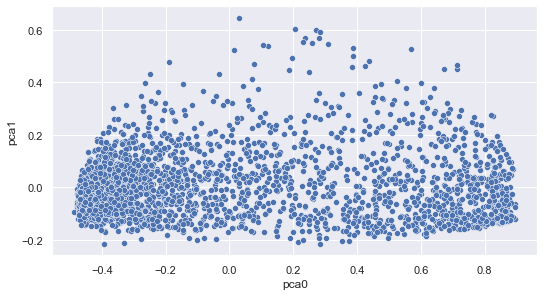

In [32]:
# sns.set_theme(rc={'figure.figsize':(8.69,0.58)})
sns.set_theme(rc={'figure.figsize':(8.69,4.58)}) # Actual ratio above
sns.scatterplot(data=df, x='pca0', y='pca1')

<AxesSubplot:xlabel='pca0', ylabel='pca1'>

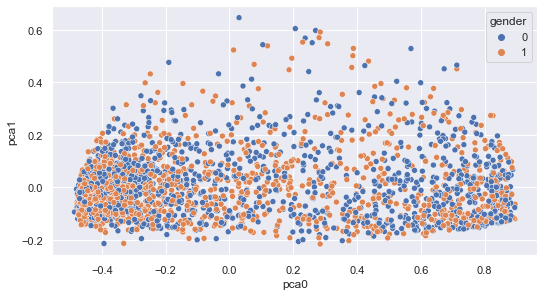

In [33]:
sns.scatterplot(data=df, x='pca0', y='pca1', hue='gender')

Looks to me like there are more women's utterances on the right (pca0 > 0.2). How can we check that? What does it mean?

<AxesSubplot:xlabel='pca0', ylabel='pca1'>

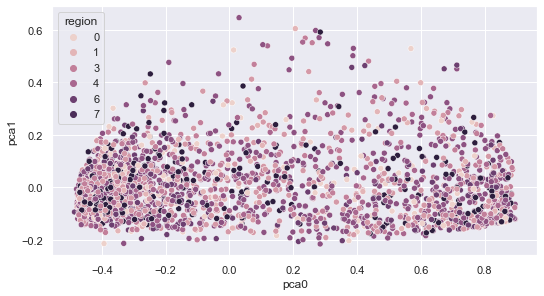

In [34]:
sns.scatterplot(data=df, x='pca0', y='pca1', hue='region')

<AxesSubplot:xlabel='pca0', ylabel='pca1'>

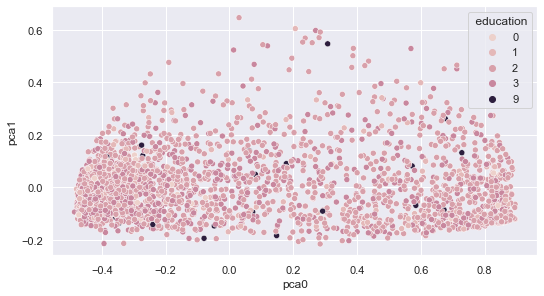

In [37]:
sns.scatterplot(data=df, x='pca0', y='pca1', hue=' education')

Hard to see any pattern here. It's possible that there's an over-representation of some educations.

<AxesSubplot:xlabel='pca0', ylabel='pca1'>

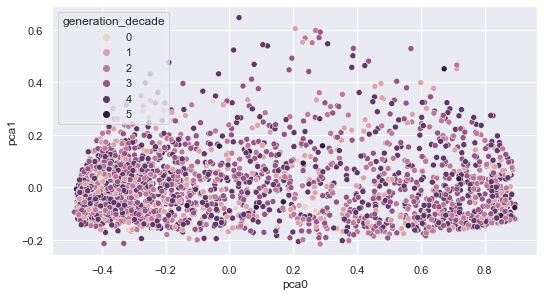

In [38]:
sns.scatterplot(data=df, x='pca0', y='pca1', hue='generation_decade')

<AxesSubplot:xlabel='pca0', ylabel='pca1'>

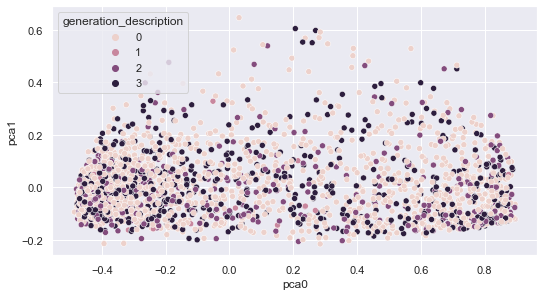

In [39]:
sns.scatterplot(data=df, x='pca0', y='pca1', hue='generation_description')

Not really sure, but there may be clusters in the generational data.

<AxesSubplot:xlabel='generation_decade', ylabel='pca0'>

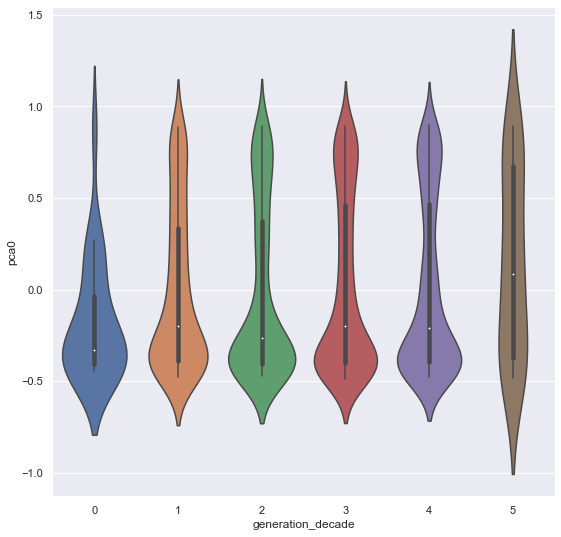

In [41]:
sns.set_theme(rc={'figure.figsize':(9,9)})
sns.violinplot(data=df, x='generation_decade', y='pca0')
# Before, when the labels were present, I also imposed an order, ala: order=[' 1920s', ' 1930s', ' 1940s', ' 1950s', ' 1960s', ' 1970s'])

The means, and shapes are different. One of these things is not like the others, but I'm not sure:

* Which one is different to the others?
* What that implies?

Let's get the answer to at least the first question.

In [42]:
gen_decade_encoder.inverse_transform([5])

array([' 1970s'], dtype=object)

GenX-ers are the oddballs... my people!

Okay, so it's interesting this only came out in the violin plot. What else is there?

<AxesSubplot:xlabel='gender', ylabel='pca0'>

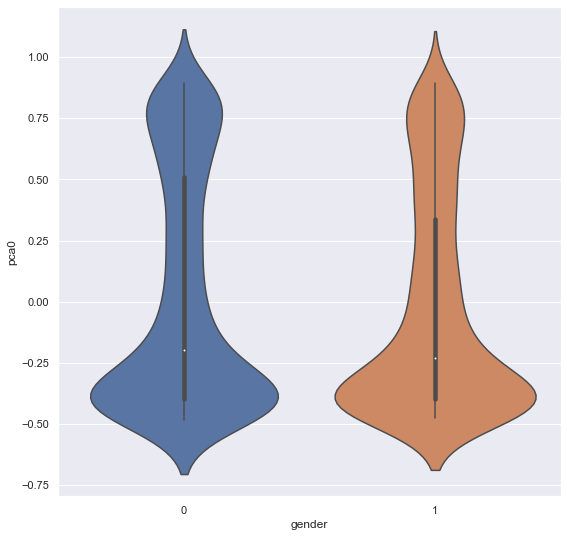

In [44]:
sns.violinplot(data=df, x='gender', y='pca0')

<AxesSubplot:xlabel='region', ylabel='pca0'>

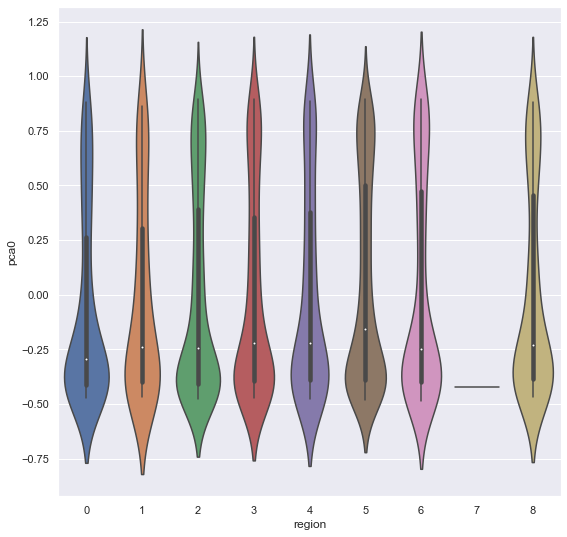

In [48]:
sns.violinplot(data=df, x='region', y='pca0')

Not much of a difference with those two, IMHO.

<AxesSubplot:xlabel=' education', ylabel='pca0'>

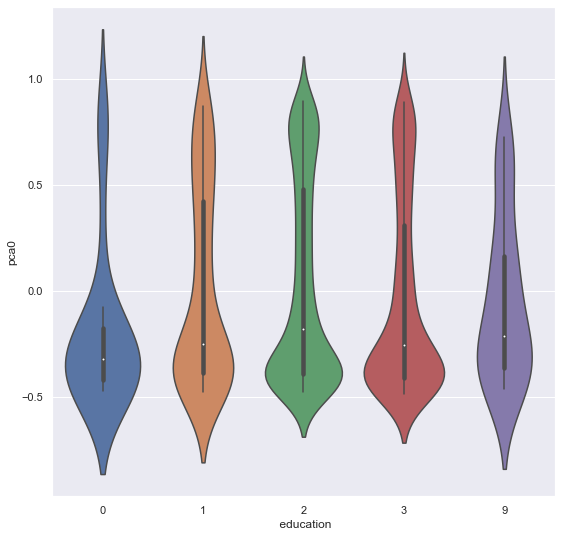

In [46]:
sns.violinplot(data=df, x=' education', y='pca0')

A small difference with education = 9. (Those are the unknown ones, right?)

<AxesSubplot:xlabel='pca0', ylabel='Count'>

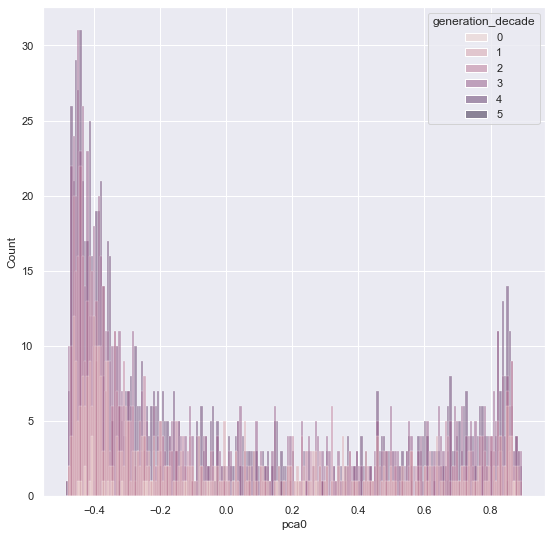

In [43]:
sns.histplot(data=df, x='pca0', bins=200, hue='generation_decade')

I think this dataset is too noisy... maybe because it's not rolled up by speaker averages?

# Switchboard... by speaker?

In [49]:
# Better to use groupby, as in cell below

# speaker_df = pd.DataFrame(df[' speaker'].unique())
# speaker_df = speaker_df.rename(columns={0:'Speaker'})

# speaker_df

In [50]:
speaker_df = df.groupby(' speaker')
speaker_df

In [51]:
speaker_df.describe()

Unnamed: 0                                             \
                       count         mean          std     min      25%   
 speaker                                                                  
 Switchboard.1000        3.0   634.333333   959.773063    16.0    81.50   
 Switchboard.1001       10.0  1509.600000   448.936818  1199.0  1201.25   
 Switchboard.1002       10.0  1516.300000   754.355950   134.0   893.75   
 Switchboard.1004        5.0  1450.600000  1009.654050   452.0   453.00   
 Switchboard.1005       11.0   949.545455   993.427336    53.0   244.00   
...                      ...          ...          ...     ...      ...   
 Switchboard.1687        3.0  2502.000000   712.739083  1679.0  2296.00   
 Switchboard.1689        1.0  2925.000000          NaN  2925.0  2925.00   
 Switchboard.1691        1.0  2915.000000          NaN  2915.0  2915.00   
 Switchboard.1695        4.0  1975.500000   617.000540  1666.0  1666.75   
 Switchboard.1697        1.0  2922.000000          NaN  2922.0  2922.00   

                                           start time              ...  \
                      50%      75%     max      count        mean  ...   
 speaker                                                           ...   
 Switchboard.1000   147.0   943.50  1740.0        3.0  122.397625  ...   
 Switchboard.1001  1480.5  1528.75  2702.0       10.0  186.556150  ...   
 Switchboard.1002  1871.5  1987.75  2582.0       10.0  212.354100  ...   
 Switchboard.1004  1569.0  1997.00  2782.0        5.0  190.435650  ...   
 Switchboard.1005   525.0  1421.50  2723.0       11.0  255.871989  ...   
...                   ...      ...     ...        ...         ...  ...   
 Switchboard.1687  2913.0  2913.50  2914.0        3.0  167.109208  ...   
 Switchboard.1689  2925.0  2925.00  2925.0        1.0  145.560750  ...   
 Switchboard.1691  2915.0  2915.00  2915.0        1.0   58.860375  ...   
 Switchboard.1695  1667.5  1976.25  2901.0        4.0  132.624937  ...   
 Switchboard.1697  2922.0  2922.00  2922.0        1.0   85.803625  ...   

                       pca5            pca6                          \
                        75%       max count          mean       std   
 speaker                                                              
 Switchboard.1000  0.000198  0.000561   3.0  1.054953e-04  0.000133   
 Switchboard.1001  0.000278  0.000454  10.0  1.277121e-04  0.000109   
 Switchboard.1002  0.001155  0.002497  10.0 -5.883637e-05  0.000089   
 Switchboard.1004  0.001332  0.003507   5.0  4.456713e-05  0.000047   
 Switchboard.1005  0.000837  0.002962  11.0  1.919874e-04  0.000295   
...                     ...       ...   ...           ...       ...   
 Switchboard.1687  0.000678  0.001144   3.0  3.203304e-05  0.000049   
 Switchboard.1689 -0.000115 -0.000115   1.0  1.556577e-04       NaN   
 Switchboard.1691  0.000295  0.000295   1.0 -1.034710e-04       NaN   
 Switchboard.1695  0.000735  0.000787   4.0 -1.340119e-05  0.000091   
 Switchboard.1697  0.000104  0.000104   1.0 -7.176066e-07       NaN   

                                                                           \
                            min           25%           50%           75%   
 speaker                                                                    
 Switchboard.1000  2.847723e-05  2.853530e-05  2.859337e-05  1.440044e-04   
 Switchboard.1001  1.030493e-05  3.014687e-05  1.115842e-04  2.247625e-04   
 Switchboard.1002 -1.624782e-04 -1.269747e-04 -9.897835e-05  3.964996e-05   
 Switchboard.1004 -1.700725e-05  2.257782e-05  4.847162e-05  5.755467e-05   
 Switchboard.1005 -1.466441e-04  2.174488e-05  1.151711e-04  1.767655e-04   
...                         ...           ...           ...           ...   
 Switchboard.1687  3.111561e-06  3.953464e-06  4.795366e-06  4.649377e-05   
 Switchboard.1689  1.556577e-04  1.556577e-04  1.556577e-04  1.556577e-04   
 Switchboard.1691 -1.034710e-04 -1.034710e-04 -1.034710e-04 -1.034710e-04   
 Switchboar

In [52]:
# This will list 3 elements from the first grouping
# list(speaker_df)[3]

In [53]:
median_speaker_df = speaker_df.median()

In [54]:
median_speaker_df

,Unnamed: 0,start time,end time,speech rate,utterance,repitition,pronoun rate,loudness,pitch,generation_year,...,region,utterance duration,tokens,pca0,pca1,pca2,pca3,pca4,pca5,pca6
speaker,,,,,,,,,,,,,,,,,,,,,
Switchboard.1000,147.0,145.954875,154.289500,11.980,14.0,54.0,3.45,0.010,208.900,1954.0,...,5.0,8.764250,16.0,-0.337617,-0.009841,0.021193,0.014542,0.036659,-0.000164,2.859337e-05
Switchboard.1001,1480.5,193.913563,197.992188,18.445,16.0,44.5,4.17,0.015,112.105,1940.0,...,8.0,5.700938,17.0,-0.227752,-0.063730,-0.067205,0.026369,0.002076,-0.000019,1.115842e-04
Switchboard.1002,1871.5,177.094063,183.766938,17.935,16.0,41.0,6.19,0.000,225.985,1963.0,...,6.0,5.984125,17.0,-0.212211,0.012421,0.035811,0.009514,-0.003229,0.000597,-9.897835e-05
Switchboard.1004,1569.0,126.341000,129.130750,39.190,5.0,12.0,0.00,0.010,193.540,1958.0,...,3.0,2.679125,7.0,0.609836,-0.111217,0.028181,0.049929,-0.001408,0.000576,4.847162e-05
Switchboard.1005,525.0,238.596375,240.431875,27.450,5.0,11.0,4.76,0.020,207.960,1956.0,...,8.0,3.824625,6.0,0.519181,-0.024157,0.022243,0.020026,-0.004476,0.000427,1.151711e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Switchboard.1687,2913.0,151.716125,165.818375,7.810,26.0,76.0,2.86,0.010,118.640,1962.0,...,3.0,13.442250,27.0,-0.444499,-0.013324,0.065410,0.057453,0.025705,0.000212,4.795366e-06
Switchboard.1689,2925.0,145.560750,155.614125,10.440,16.0,71.0,5.00,0.020,95.820,1945.0,...,2.0,10.053375,17.0,-0.389406,-0.088052,-0.171861,0.048537,0.044435,-0.000115,1.556577e-04
Switchboard.1691,2915.0,58.860375,69.465875,9.900,28.0,72.0,2.63,0.000,78.330,1969.0,...,5.0,10.605500,29.0,-0.420177,-0.044627,0.010808,0.039935,0.012417,0.000295,-1.034710e-04


In [55]:
median_speaker_df.columns

Index(['Unnamed: 0', 'start time', 'end time', 'speech rate', 'utterance',
       'repitition', 'pronoun rate', 'loudness', 'pitch', ' generation_year',
       ' education', 'material', 'generation_description', 'generation_decade',
       'gender', 'region', 'utterance duration', 'tokens', 'pca0', 'pca1',
       'pca2', 'pca3', 'pca4', 'pca5', 'pca6'],
      dtype='object')

<AxesSubplot:xlabel='pca0', ylabel='pca1'>

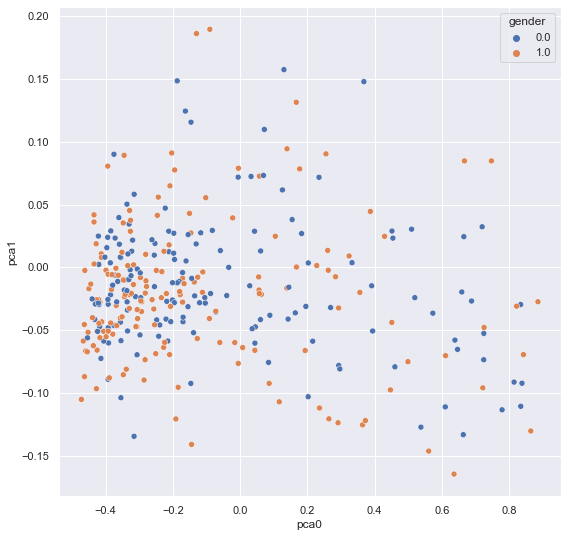

In [57]:
sns.scatterplot(data=median_speaker_df, x='pca0', y='pca1', hue='gender')

<AxesSubplot:xlabel='pca0', ylabel='Count'>

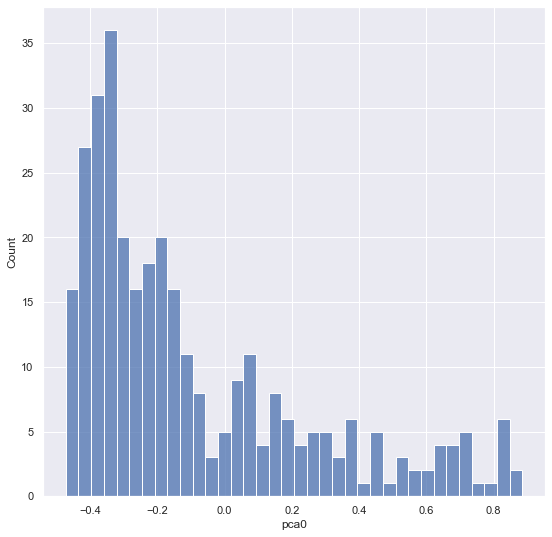

In [65]:
sns.histplot(data=median_speaker_df, x='pca0', bins=36)

<AxesSubplot:xlabel='pca0', ylabel='Count'>

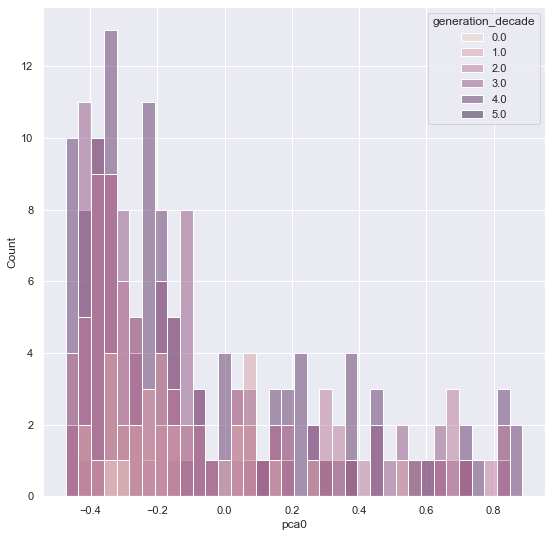

In [66]:
sns.histplot(data=median_speaker_df, x='pca0', hue='generation_decade', bins=36)

<AxesSubplot:xlabel='generation_decade', ylabel='pca0'>

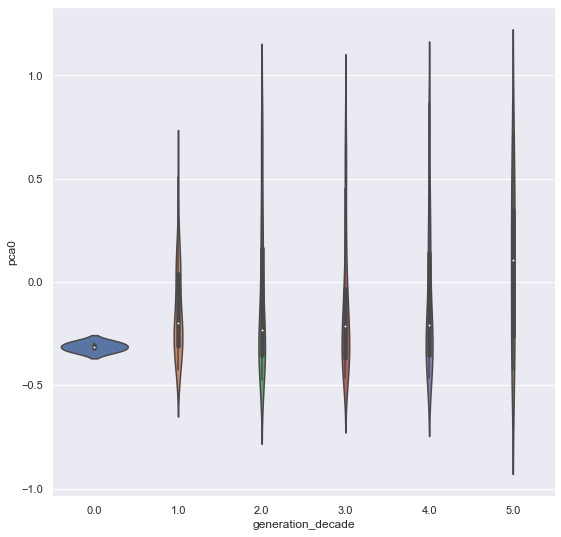

In [67]:
sns.violinplot(data=median_speaker_df, x='generation_decade', y='pca0')

<AxesSubplot:xlabel='generation_description', ylabel='pca0'>

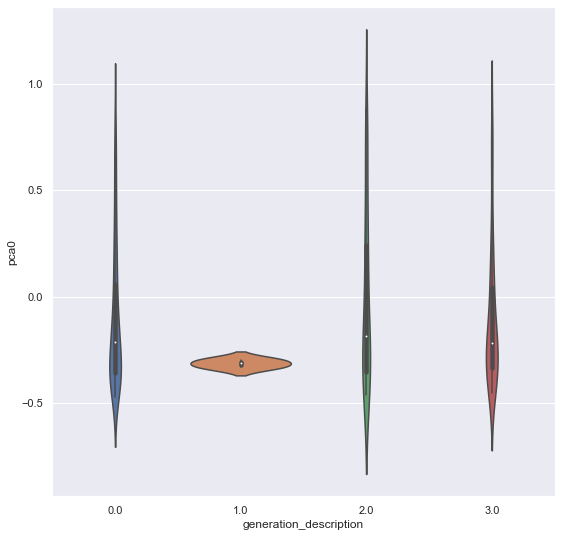

In [68]:
sns.violinplot(data=median_speaker_df, x='generation_description', y='pca0')

In [69]:
gen_description_encoder.inverse_transform([0, 1, 2, 3])

array([' Baby_Boomer', ' GI', ' Generation_X', ' Silent'], dtype=object)

In [70]:
median_speaker_df.loc[median_speaker_df['generation_description'] == 1.0]

,Unnamed: 0,start time,end time,speech rate,utterance,repitition,pronoun rate,loudness,pitch,generation_year,...,region,utterance duration,tokens,pca0,pca1,pca2,pca3,pca4,pca5,pca6
speaker,,,,,,,,,,,,,,,,,,,,,
Switchboard.1381,2614.0,112.232438,115.216375,12.47,15.5,42.5,4.650,0.00,170.585,1924.0,...,5.0,8.824562,16.5,-0.297405,-0.004439,0.047838,0.020141,0.031361,0.000569,-0.000128
Switchboard.1402,1487.0,104.843875,112.129063,15.33,18.0,56.5,4.555,0.01,108.080,1924.0,...,6.0,6.893062,19.0,-0.329877,-0.032731,-0.056256,0.000268,-0.004103,0.000067,0.000035


<AxesSubplot:xlabel='pca0', ylabel='pca1'>

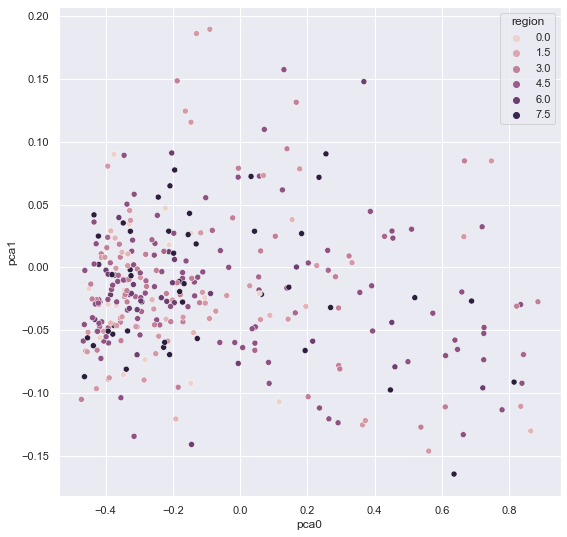

In [71]:
sns.scatterplot(data=median_speaker_df, x='pca0', y='pca1', hue='region')

# Testing new datasets

In [83]:
lab_df = pd.read_csv('labeled_data_with_interaction_labels.csv')
new_df = pd.read_csv('new-features-switchboard-dataset.csv')
joined_df = pd.concat([lab_df, new_df], axis=1)
joined_df

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)  # Fill numerical NaNs with median
df.fillna('', inplace=True)  # Fill categorical NaNs with empty string


,Unnamed: 0,file,start time,end time,sentence,speech rate,utterance,repitition,pronoun rate,loudness,...,loudness range,pronoun rate,generation decade,gender,region,education,turn_length,syllable_count,sentiment_score,pitch_variability
0,0.0,2005A.U20.wav,1970-01-01 00:00:00.000000173,1970-01-01 00:00:00.000000185,yeah well my uh my,9.27,4.0,7.0,0.00,0.00,...,0.054686,0.14,1940s,male,southern,3.0,20.0,30,0.1406,9.602312
1,1.0,2005A.U23.wav,1970-01-01 00:00:00.000000208,1970-01-01 00:00:00.000000221,finding a place and everybody had duties to pe...,8.55,35.0,107.0,0.00,0.00,...,0.064026,0.05,1940s,male,southern,3.0,20.0,33,0.4939,15.196808
2,2.0,2005A.U24.wav,1970-01-01 00:00:00.000000221,1970-01-01 00:00:00.000000235,and they i know they and well they had well th...,7.42,17.0,16.0,5.56,0.01,...,0.062381,0.07,1940s,male,southern,3.0,14.0,18,0.3612,14.484177
3,3.0,2005A.U42.wav,1970-01-01 00:00:00.000000334,1970-01-01 00:00:00.000000344,it was not necessarily you know like the quant...,10.45,22.0,67.0,11.11,0.02,...,0.026196,0.09,1940s,male,southern,3.0,10.0,12,0.2960,9.864243
4,4.0,2005A.U52.wav,1970-01-01 00:00:00.000000390,1970-01-01 00:00:00.000000401,we we don't we we we choose not to deal with t...,10.05,31.0,88.0,8.33,0.01,...,0.048944,0.05,1940s,male,southern,3.0,20.0,35,0.0772,8.600034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.037665,0.12,1950s,male,southern,2.0,7.0,8,0.2960,18.336728
15457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.037665,0.00,1950s,male,southern,2.0,7.0,8,0.2960,18.336728
15458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.037665,0.12,1950s,male,southern,2.0,0.0,1,0.0000,18.336728
15459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.037665,0.00,1950s,male,southern,2.0,0.0,1,0.0000,18.336728


In [85]:
joined_df = joined_df[joined_df['file'].notna()]
joined_df

,Unnamed: 0,file,start time,end time,sentence,speech rate,utterance,repitition,pronoun rate,loudness,...,loudness range,pronoun rate,generation decade,gender,region,education,turn_length,syllable_count,sentiment_score,pitch_variability
0,0.0,2005A.U20.wav,1970-01-01 00:00:00.000000173,1970-01-01 00:00:00.000000185,yeah well my uh my,9.27,4.0,7.0,0.00,0.00,...,0.054686,0.14,1940s,male,southern,3.0,20.0,30,0.1406,9.602312
1,1.0,2005A.U23.wav,1970-01-01 00:00:00.000000208,1970-01-01 00:00:00.000000221,finding a place and everybody had duties to pe...,8.55,35.0,107.0,0.00,0.00,...,0.064026,0.05,1940s,male,southern,3.0,20.0,33,0.4939,15.196808
2,2.0,2005A.U24.wav,1970-01-01 00:00:00.000000221,1970-01-01 00:00:00.000000235,and they i know they and well they had well th...,7.42,17.0,16.0,5.56,0.01,...,0.062381,0.07,1940s,male,southern,3.0,14.0,18,0.3612,14.484177
3,3.0,2005A.U42.wav,1970-01-01 00:00:00.000000334,1970-01-01 00:00:00.000000344,it was not necessarily you know like the quant...,10.45,22.0,67.0,11.11,0.02,...,0.026196,0.09,1940s,male,southern,3.0,10.0,12,0.2960,9.864243
4,4.0,2005A.U52.wav,1970-01-01 00:00:00.000000390,1970-01-01 00:00:00.000000401,we we don't we we we choose not to deal with t...,10.05,31.0,88.0,8.33,0.01,...,0.048944,0.05,1940s,male,southern,3.0,20.0,35,0.0772,8.600034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,2922.0,4877B.U18.wav,1970-01-01 00:00:00.000000085,1970-01-01 00:00:00.000000097,and and then i have my um um i have a seven mo...,9.04,37.0,111.0,5.56,0.01,...,0.013572,0.07,1930s,female,new_england,1.0,14.0,15,0.4019,13.497298
2923,2923.0,4880A.U23.wav,1970-01-01 00:00:00.000000135,1970-01-01 00:00:00.000000144,ititit yes okay andand our company has taken t...,11.32,18.0,57.0,10.53,0.02,...,0.017434,0.06,1930s,female,new_england,1.0,17.0,23,0.0000,13.292160
2924,2924.0,4880A.U27.wav,1970-01-01 00:00:00.000000162,1970-01-01 00:00:00.000000165,uh laughter-and and uh,32.26,3.0,18.0,0.00,0.02,...,0.017434,0.00,1930s,female,new_england,1.0,17.0,23,0.0000,13.292160
2925,2925.0,4908B.U21.wav,1970-01-01 00:00:00.000000145,1970-01-01 00:00:00.000000155,uh waste material in general and um and purify...,10.44,16.0,71.0,5.00,0.02,...,0.017434,0.06,1930s,female,new_england,1.0,0.0,1,0.0000,13.292160


In [76]:
junk_df.turn_gap.tail()

2922      0 days 00:00:00.000000038
2923      0 days 00:00:00.000000018
2924    -1 days +23:59:59.999999980
2925      0 days 00:00:00.000000029
2926                            NaN
Name: turn_gap, dtype: object

In [77]:
junk_df = pd.read_csv('new-features-switchboard-dataset.csv')
junk_df

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)  # Fill numerical NaNs with median
df.fillna('', inplace=True)  # Fill categorical NaNs with empty string


,Unnamed: 0,Unnamed: 0.1,file name,start time,end time,sentence,speech rate,utterance,repetition,pitch mean,...,loudness range,pronoun rate,generation decade,gender,region,education,turn_length,syllable_count,sentiment_score,pitch_variability
0,0,0,4519A.U11.wav,67.937250,74.965125,well we stay within our means but we do not d...,12.236985,20.0,0,96.116771,...,0.054686,0.14,1940s,male,southern,3.0,20.0,30,0.1406,9.602312
1,1,1,4519A.U12.wav,74.965125,84.399125,although we just moved to California and the c...,9.115964,20.0,1,111.039522,...,0.064026,0.05,1940s,male,southern,3.0,20.0,33,0.4939,15.196808
2,2,2,4519A.U13.wav,84.399125,93.255250,housing prices are you know like from four to ...,9.710793,14.0,0,104.010662,...,0.062381,0.07,1940s,male,southern,3.0,14.0,18,0.3612,14.484177
3,3,3,4519A.U14.wav,93.255250,104.642125,they were where i came from in Dallas noise y...,7.552555,10.0,0,97.932426,...,0.026196,0.09,1940s,male,southern,3.0,10.0,12,0.2960,9.864243
4,4,4,4519A.U15.wav,104.642125,117.394625,that presents a real shock laughter actuallya...,6.743776,20.0,0,88.057037,...,0.048944,0.05,1940s,male,southern,3.0,20.0,35,0.0772,8.600034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15456,15456,17626,2398B.U42.wav,153.153750,155.850875,yeah what now what state are you in,31.885804,7.0,0,130.487833,...,0.037665,0.12,1950s,male,southern,2.0,7.0,8,0.2960,18.336728
15457,15457,17627,2398B.U42.wav,153.153750,155.850875,yeah what now what state are you in,31.885804,7.0,0,130.487833,...,0.037665,0.00,1950s,male,southern,2.0,7.0,8,0.2960,18.336728
15458,15458,17628,2398B.U42.wav,557.961125,559.123250,gee,74.002366,0.0,0,130.487833,...,0.037665,0.12,1950s,male,southern,2.0,0.0,1,0.0000,18.336728
15459,15459,17629,2398B.U42.wav,557.961125,559.123250,gee,74.002366,0.0,0,130.487833,...,0.037665,0.00,1950s,male,southern,2.0,0.0,1,0.0000,18.336728


In [86]:
joined_df.columns

Index(['Unnamed: 0', 'file', 'start time', 'end time', 'sentence',
       'speech rate', 'utterance', 'repitition', 'pronoun rate', 'loudness',
       'pitch', ' material', ' speaker', ' generation_description',
       ' generation_decade', ' gender', ' region', ' generation_year', ' L1',
       ' corpus', ' education', 'duration', 'turn_gap', 'turn_type',
       'interaction_label', 'Unnamed: 0', 'Unnamed: 0.1', 'file name',
       'start time', 'end time', 'sentence', 'speech rate', 'utterance',
       'repetition', 'pitch mean', 'pitch std dev', 'pitch range',
       'loudness mean', 'loudness std dev', 'loudness range', 'pronoun rate',
       'generation decade', 'gender', 'region', 'education', 'turn_length',
       'syllable_count', 'sentiment_score', 'pitch_variability'],
      dtype='object')

In [79]:
junk_df.shape

(15461, 24)